This notebook contains all code for the visualizations presented in the paper, containing both main paper as well as appendix figures

In [1]:
pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 225.9 kB/s  0:00:36m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from scipy import stats
from scipy.stats import norm
import pingouin as pg
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import chi2_contingency
from collections import Counter
from pywaffle import Waffle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import LogLocator
import statsmodels.formula.api as smf
import re

In [3]:
path = "/Users/XXX1/Documents/GitHub/rita_survey/"
#path = "/home/XXX4/postdoc/it_survey/rita_survey/"

In [4]:
c1 = '#2E86AB'
c2 = '#A23B72'

tri_palette_colors = ['#2E86AB', '#A23B72', '#95a5a6']

blues_palette = ['#1B4F72', '#2E86AB', '#5BA3C5', '#8DC4DC', '#BFE0EE']

sns.set_theme("notebook", style="whitegrid", font_scale=1.3)

# Load df

In [5]:
#load the data and skip second row (translated header)
df_clean = pd.read_csv(path+"survey_v3_clean.tsv", sep="\t", skiprows=[1], encoding='utf-8')
df_clean.head(3)

,StartDate,EndDate,Status,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,DistributionChannel,UserLanguage,...,future_use,future_use_7_TEXT,Q_DataPolicyViolations,Q_StraightliningCount,Q_StraightliningPercentage,Q_StraightliningQuestions,Q_UnansweredPercentage,Q_UnansweredQuestions,mapped_job,weight
0,2025-05-23 2:23:05,2025-05-23 2:29:09,IP Address,100,363,True,2025-05-23 2:29:09,R_8zCIYRTtI5tvimW,anonymous,IT,...,NaN,NaN,NaN,0,0.0,NaN,0.078947,"QID46,QID48,QID85",Impresa e consulenza aziendale,0.49
1,2025-05-23 2:27:17,2025-05-23 2:32:43,IP Address,100,325,True,2025-05-23 2:32:43,R_2ZE9jb0FUPux0tt,anonymous,IT,...,NaN,NaN,NaN,0,0.0,NaN,0.093750,"QID46,QID48,QID85",Finanza,0.58
2,2025-05-23 2:33:42,2025-05-23 2:39:23,IP Address,100,341,True,2025-05-23 2:39:24,R_8CT67Tz9qI28TCL,anonymous,IT,...,NaN,NaN,NaN,1,0.5,QID51,0.083333,"QID46,QID48,QID85",Ricerca e accademia,0.49


In [6]:
# Discard NA values for chatbot adoption question
df_clean = df_clean[df_clean['Q43'].notna()].copy()
len(df_clean)

1906

# Variables 

Define variables used in the visualization and paper

## Demographics

In [7]:
# Mapping education
education_map = {k: 'Graduates' for k in [
    'Laurea magistrale o master di primo livello',
    'Laurea triennale o a ciclo unico',
    'Dottorato di ricerca',
    'Master di secondo livello'
]}
education_map.update({k: 'Non-graduates' for k in [
    'Diploma di scuola superiore',
    'Istruzione secondaria di primo grado (medie)', 
    'Istruzione primaria (elementari)'
]})

# Mapping geography
def geography_map(x):
    if x in ['Nord-Ovest, Italia', 'Nord-Est, Italia']:
        return 'North'
    elif x in ['Sud Italia', 'Isole, Italia']:
        return 'South and Islands'
    elif x == 'Centro Italia':
        return 'Centre'
    elif x == 'Non vivo in Italia':
        return 'Abroad'

# Mapping gender
def gender_map(x):
    if x == 'Uomo':
        return 'Man'
    elif x == 'Donna':
        return 'Woman'
    else:
        return 'Neither'

# Mapping income
def income_map(x):
    if x in ['Bassa', 'Medio Bassa']:
        return 'Lower'
    elif x in ['Medio Alta', 'Alta']:
        return 'Higher'
    elif x == 'Media':
        return 'Mid'

def age_map(x):
    if x in ['18-24 anni', '25-34 anni']:
        return '18-34'
    elif x in ['35-44 anni', '45-54 anni']:
        return '35-54'
    elif x == '55-64 anni':
        return '55-64'
    else:
        return '65+'

In [8]:
df_clean['EducationGroup'] = df_clean['Istruzione'].map(education_map)
df_clean['GeographyGroup'] = df_clean['Q10'].apply(geography_map)
df_clean['GenderGroup'] = df_clean['Q17'].apply(gender_map)
df_clean['IncomeGroup'] = df_clean['Q16'].apply(income_map)
df_clean['AgeGroup'] = df_clean['Q6'].apply(age_map)

## Chatbot users vs non-users

In [9]:
# Column for chatbot usage
chatbot_col = 'Q43'

# Check if column exists
if chatbot_col in df_clean.columns:
    # Create chatbot_user column
    # If contains "Non ho mai usato" = No (not a user)
    # Otherwise = Yes (is a user)
    df_clean['chatbot_user'] = df_clean['Q43'].str.contains("Non ho mai usato", case=False, na=False).map({True: 'No', False: 'Yes'})

In [10]:
print(f"Chatbot users: {(df_clean['chatbot_user'] == 'Yes').sum()}")
print(f"Non-users: {(df_clean['chatbot_user'] == 'No').sum()}")

Chatbot users: 1533
Non-users: 373


## LT experience index

In [11]:
# Define the columns for LT experience
columns = {
    'Q20-MT': 'MT',
    'Q21': 'Vocal Assistants',
    'Q33': 'Assisted Writing',
    'Q34': 'Speech Transcript',
    'Q36': 'Text-to-Speech',
}


lt_exp = pd.Series(0, index=df_clean.index)
# For each column, check if they have used it (NOT "Non ho mai usato")
for col in columns.keys():
    if col in df_clean.columns:
        # Check if the response does NOT contain "Non ho mai usato"
        # This means they HAVE used it (= 1 point)
        has_used = ~df_clean[col].fillna("Non ho mai usato").str.contains(
            "Non ho mai usato", 
            case=False, 
            na=False
        )
        lt_exp += has_used.astype(int)
    else:
        print(f"Warning: Column '{col}' not found in dataframe")

# Add to dataframe
df_clean['LT_exp'] = lt_exp

## Literacy index

In [12]:
# Define the Likert scale columns for LT literacy
lt_lit_columns = ['likert_1_1', 'likert_1_3', 'likert_1_4', 'likert_1_5', 
                  'likert_2_1', 'likert_2_2', 'likert_2_3']

# Likert labels (for reference)
likert_labels = {
    0: "Per niente d'accordo",
    1: "Poco d'accordo",
    2: "Non so",
    3: "Abbastanza d'accordo",
    4: "Totalmente d'accordo"
}

# Check which columns exist
existing_cols = [col for col in lt_lit_columns if col in df_clean.columns]
missing_cols = [col for col in lt_lit_columns if col not in df_clean.columns]

if missing_cols:
    print(f"Warning: Missing columns: {missing_cols}")

if existing_cols:
    # Calculate row mean of the Likert scale responses (0-4)
    df_clean['lt_lit01'] = df_clean[existing_cols].mean(axis=1)
    df_clean['lt_lit'] = df_clean['lt_lit01'] / 4

## Intent Frequency

In [13]:
intent_mapping = {
    'Q51_1': 'InfoRetrieval',
    'Q51_2': 'ProblemSolving',
    'Q51_3': 'Learning',
    'Q51_4': 'ContentCreation',
    'Q51_5': 'Entertainment',
    'Q51_6': 'Creativity'
}

# Define frequency order
freq_order = ["Mai", "Meno di una volta al mese", "Almeno una volta al mese", "Almeno una volta a settimana"]

# Create numerical mapping
freq_to_num = {
    "Mai": 0,
    "Meno di una volta al mese": 1,
    "Almeno una volta al mese": 2,
    "Almeno una volta a settimana": 3
}

# Convert each intent column to numerical frequency in df_clean
for old_col, new_col in intent_mapping.items():
    if old_col in df_clean.columns:
        # Create numerical version (will be NaN for non-users who don't have responses)
        df_clean[f'{new_col}_freq'] = df_clean[old_col].map(freq_to_num)

# Main Paper Figures

## Logit GenAI usage (users vs nont users)

In [27]:
# Create dataframe from logistic regression results
logit_r_genai = pd.DataFrame({
    'variable': ['Woman', '35-54', '55-64', '65+', 'Graduates', 'Mid', 'Higher', 
                 'Center', 'South&Islands', 'Abroad', 'LT experience', 'LT literacy'],
    'category': ['Gender (Man)', 'Age (18-34)', 'Age (18-34)', 'Age (18-34)', 'Education (Non-graduates)', 'Income (Lower)', 'Income (Lower)',
                 'Geography (North)', 'Geography (North)', 'Geography (North)',  'LT experience', 'LT literacy'],
    'odds_ratio': [0.5001689, 0.4405143, 0.3687476, 0.1927583, 1.483451, 1.303735, 1.719509,
                   1.069195, 0.7967935, 0.7829271, 1.697836, 21.80742],
    'standard_error': [0.0709603, 0.0983435, 0.08431, 0.0431987, 
                        0.2191478, 0.2361036, 0.3742066, 0.2033392,
                        0.1466317, 0.2728541, 0.1233862, 7.078729],  
    'ci_lower': [0.3787516, 0.2844014, 0.2355654, 0.1242372, 1.11052, 0.914194, 1.122439,
                 0.7365047, 0.5555223, 0.3954333, 1.472436, 10.85298],
    'ci_upper': [0.6605093, 0.6822262, 0.5772273, 0.2996711, 1.981617, 1.85926, 2.634186,
                 1.552166, 1.142852, 1.550135, 1.957739, 48.66272],
    'p_value': [0.000, 0.000, 0.000, 0.000, 0.008, 0.143, 0.013, 
                0.725, 0.217, 0.483, 0.000, 0.000],
    'significant': [True, True, True, True, True, False, True, 
                   False, False, False, True, True]
})

In [28]:
logit_r_genai[['variable','category', 'odds_ratio', 'standard_error','significant']]

,variable,category,odds_ratio,standard_error,significant
0,Woman,Gender (Man),0.500169,0.070960,True
1,35-54,Age (18-34),0.440514,0.098344,True
2,55-64,Age (18-34),0.368748,0.084310,True
3,65+,Age (18-34),0.192758,0.043199,True
4,Graduates,Education (Non-graduates),1.483451,0.219148,True
5,Mid,Income (Lower),1.303735,0.236104,False
6,Higher,Income (Lower),1.719509,0.374207,True
7,Center,Geography (North),1.069195,0.203339,False
8,South&Islands,Geography (North),0.796794,0.146632,False
9,Abroad,Geography (North),0.782927,0.272854,False


In [29]:
table = logit_r_genai[['variable','category','odds_ratio','standard_error','significant']].copy()

table['odds_ratio'] = table['odds_ratio'].round(3)
table['standard_error'] = table['standard_error'].round(3)

def format_variable(row):
    if "(" in row['category']:
        cat, ref = row['category'].split("(", 1)
        cat = cat.strip()
        ref = ref.replace(")", "").strip()
        return f"{cat}: {row['variable']} ({ref})"
    else:
        return f"{row['category']}"

table['variable'] = table.apply(format_variable, axis=1)

table['significant'] = table['significant'].apply(lambda x: "**" if x else "")

table = table[['variable','odds_ratio','standard_error','significant']]
table

,variable,odds_ratio,standard_error,significant
0,Gender: Woman (Man),0.500,0.071,**
1,Age: 35-54 (18-34),0.441,0.098,**
2,Age: 55-64 (18-34),0.369,0.084,**
3,Age: 65+ (18-34),0.193,0.043,**
4,Education: Graduates (Non-graduates),1.483,0.219,**
5,Income: Mid (Lower),1.304,0.236,
6,Income: Higher (Lower),1.720,0.374,**
7,Geography: Center (North),1.069,0.203,
8,Geography: South&Islands (North),0.797,0.147,
9,Geography: Abroad (North),0.783,0.273,


In [30]:
latex_table = table.to_latex(index=False, escape=False)
print(latex_table)

\begin{tabular}{lrrl}
\toprule
variable & odds_ratio & standard_error & significant \\
\midrule
Gender: Woman (Man) & 0.500000 & 0.071000 & ** \\
Age: 35-54 (18-34) & 0.441000 & 0.098000 & ** \\
Age: 55-64 (18-34) & 0.369000 & 0.084000 & ** \\
Age: 65+ (18-34) & 0.193000 & 0.043000 & ** \\
Education: Graduates (Non-graduates) & 1.483000 & 0.219000 & ** \\
Income: Mid (Lower) & 1.304000 & 0.236000 &  \\
Income: Higher (Lower) & 1.720000 & 0.374000 & ** \\
Geography: Center (North) & 1.069000 & 0.203000 &  \\
Geography: South&Islands (North) & 0.797000 & 0.147000 &  \\
Geography: Abroad (North) & 0.783000 & 0.273000 &  \\
LT experience & 1.698000 & 0.123000 & ** \\
LT literacy & 21.807000 & 7.079000 & ** \\
\bottomrule
\end{tabular}



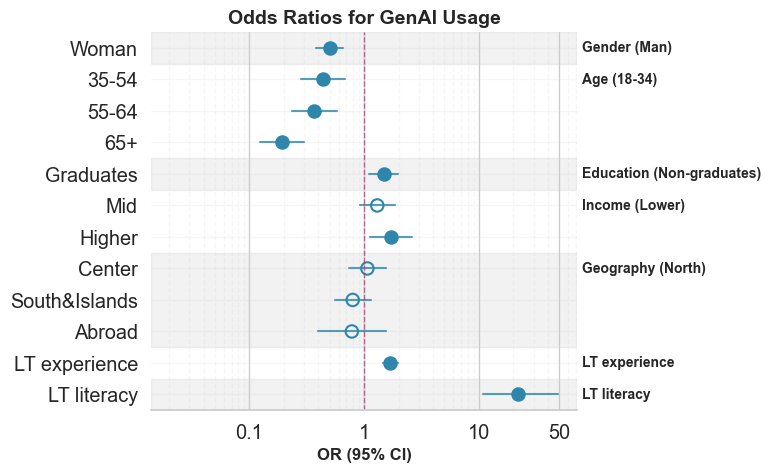

In [31]:
# Create forest plot
fig, ax = plt.subplots(figsize=(8, 5))

# Define colors and markers for significance
colors = ['#2E86AB' if sig else '#66B2C1' for sig in logit_r_genai['significant']]
markers = ['o' if sig else 's' for sig in logit_r_genai['significant']]

# Create simple evenly spaced y positions 
n_vars = len(logit_r_genai)
y_pos = list(range(n_vars-1, -1, -1)) 

# Add alternating background bands by category
categories = logit_r_genai['category'].tolist()
unique_categories = []
for cat in categories:
    if cat not in unique_categories:
        unique_categories.append(cat)

# Create bands for each category group
band_color = True  
for cat in unique_categories:
    # Find all indices for this category
    cat_indices = [i for i, row_cat in enumerate(categories) if row_cat == cat]
    
    if cat_indices:
        # Get y positions for this category
        cat_y_positions = [y_pos[i] for i in cat_indices]
        y_min = min(cat_y_positions) - 0.5
        y_max = max(cat_y_positions) + 0.5
        
        # Add band
        if band_color:  
            ax.axhspan(y_min, y_max, alpha=0.1, color='gray', zorder=0)        
        band_color = not band_color  

# Define a single color for all points and lines
main_color = tri_palette_colors[0]

# Plot odds ratios and confidence intervals
for i, (idx, row) in enumerate(logit_r_genai.iterrows()):
    # Plot CI line (always solid, same color)
    ax.plot([row['ci_lower'], row['ci_upper']], [y_pos[i], y_pos[i]],
            color=main_color, linewidth=1.5, alpha=0.8)
    
    # Plot point estimate
    if row['significant']:
        # Filled circle for significant
        ax.scatter(row['odds_ratio'], y_pos[i],
                   color=main_color, edgecolor=main_color,
                   marker='o', s=80, linewidth=1.5)
    else:
        # Hollow circle for non-significant
        ax.scatter(row['odds_ratio'], y_pos[i],
                   facecolors='none', edgecolor=main_color,
                   marker='o', s=80, linewidth=1.5)

# Add vertical line at OR = 1
ax.axvline(x=1, color=tri_palette_colors[1], linestyle='--', alpha=0.7, linewidth=1)

# Axis and Titles
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row['variable']}" for idx, row in logit_r_genai.iterrows()])
ax.set_xlabel('OR (95% CI)', fontsize=12, fontweight='bold')
ax.set_title('Odds Ratios for GenAI Usage', 
             fontsize=14, fontweight='bold')

# Calculate symmetric limits around 1 on log scale
import numpy as np
log_ors = np.log10(logit_r_genai['odds_ratio'])
log_cis = np.log10(np.concatenate([logit_r_genai['ci_lower'], logit_r_genai['ci_upper']]))
max_log_dist = max(abs(log_cis).max(), abs(log_ors).max()) * 1.1  # Add 10% padding

# Set symmetric limits around 1 on log scale
x_min = 10**(-max_log_dist)
x_max = 10**(max_log_dist)

# Set x-axis to log scale for better visualization
ax.set_xscale('log')
ax.set_xlim(x_min, x_max)

# Add custom x-axis labels showing key values
ax.set_xticks([0.1, 1, 10, 50])
ax.set_xticklabels(['0.1', '1', '10', '50'])

# Add grid lines: major in bold (optional), minor as light lines
ax.grid(which='minor', axis='x', linestyle='--', color='lightgray', alpha=0.2)
ax.grid(which='major', axis='y', linestyle='-', color='lightgray', alpha=0.2)

# Add category labels on the right (aligned with first variable of each category)
seen_categories = set()
for i, (idx, row) in enumerate(logit_r_genai.iterrows()):
    if row['category'] not in seen_categories:
        ax.text(ax.get_xlim()[1] * 1.1, y_pos[i], row['category'], fontweight='bold', 
                ha='left', va='center', fontsize=10)
        seen_categories.add(row['category'])

# Hide top and right spines
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.margins(y=0)



# Add legend (uncommented if needed)
# from matplotlib.lines import Line2D
# legend_elements = [
#     Line2D([0], [0], marker='o', color='#2E86AB', linestyle='-', 
#            label='p<0.05', markersize=8),
#     Line2D([0], [0], marker='s', color='#66B2C1', linestyle='--', 
#            label='p>0.05', markersize=8)
# ]
# ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig('../figures/or_genai.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/or_genai.pdf', dpi=300, bbox_inches='tight')
plt.show()

## LT breakdown

In [32]:
# Define mappings to calculate proportions relative the N of users of the specific application
lt_mapping = {
    'Q61': 'Q20-MT',             # MT
    'Q62': 'Q34',                # Speech Transcript
    'Q63': 'Q21',                # Vocal Assistants
    'Q64': 'Q33',                # Assisted Writing
    'Q65': 'Q36',                # Text-to-Speech
    'Q66': 'Q43'                 # Web Search replacement calculated among GenAI users
}

# Labels for what people USE (left side)
usage_labels = {
    'Q61': 'Machine Translation',
    'Q62': 'Speech Transcript',
    'Q63': 'Vocal Assistants',
    'Q64': 'Assisted Writing',
    'Q65': 'Text-to-Speech',
    'Q66': 'GenAI Chatbot'
}

# Labels for what gets REPLACED (right side) 
replacement_labels = {
    'Q61': 'Machine Translation',
    'Q62': 'Speech Transcript',
    'Q63': 'Vocal Assistants',
    'Q64': 'Assisted Writing',
    'Q65': 'Text-to-Speech',
    'Q66': 'Web Search'
}

# Calculate proportion of replacement relative to usage, with CI
# 95% CI z-score
z = norm.ppf(0.975)  
def calc_ci(p, n):
    if n == 0:
        return 0, 0
    margin = z * np.sqrt(p * (1 - p) / n)
    return p * 100, margin * 100

results = []
total = len(df_clean)

for rep_q, use_q in lt_mapping.items():
    if use_q:
        used_mask = ~df_clean[use_q].fillna("").str.contains("Non ho mai usato", case=False)
        
        denominator = used_mask.sum()
        used_pct, used_ci = calc_ci(denominator / total, total)
        rep_series = df_clean.loc[used_mask, rep_q].dropna()
    else:
        denominator = df_clean[rep_q].dropna().count()
        used_pct, used_ci = np.nan, np.nan
        rep_series = df_clean[rep_q].dropna()
    
    comp_count = (rep_series == "Completamente sostituito").sum()
    parz_count = (rep_series == "Parzialmente sostituito").sum()
    comp_pct, comp_ci = calc_ci(comp_count / denominator if denominator else 0, denominator)
    parz_pct, parz_ci = calc_ci(parz_count / denominator if denominator else 0, denominator)
    
    results.append({
        'Technology_Usage': usage_labels[rep_q],
        'Technology_Replacement': replacement_labels[rep_q],
        'Used %': round(used_pct, 1) if not np.isnan(used_pct) else np.nan,
        'Lower Used CI': round(used_pct - used_ci, 1) if not np.isnan(used_pct) else np.nan,
        'Upper Used CI': round(used_pct + used_ci, 1) if not np.isnan(used_pct) else np.nan,
        'Comp %': round(comp_pct, 1),
        'Lower Comp CI': round(comp_pct - comp_ci, 1),
        'Upper Comp CI': round(comp_pct + comp_ci, 1),
        'Parz %': round(parz_pct, 1),
        'Lower Parz CI': round(parz_pct - parz_ci, 1),
        'Upper Parz CI': round(parz_pct + parz_ci, 1),
    })

# Define fixed order for technologies
tech_order = ['Text-to-Speech', 'Assisted Writing', 'Speech Transcript', 'Vocal Assistants', 'Machine Translation', 'GenAI Chatbot']

results_df = pd.DataFrame(results)
# Reorder according to fixed order
results_df['order'] = results_df['Technology_Usage'].map({tech: i for i, tech in enumerate(tech_order)})
results_df = results_df.sort_values('order')

# Data setup
usage_techs = results_df['Technology_Usage'].values
replacement_techs = results_df['Technology_Replacement'].values
n = len(usage_techs)
indices = np.arange(n)

# Extract percentages and calculate error bars
used_pct = results_df['Used %'].values
used_err = [used_pct - results_df['Lower Used CI'].values, 
            results_df['Upper Used CI'].values - used_pct]

comp_pct = results_df['Comp %'].values
comp_err = [comp_pct - results_df['Lower Comp CI'].values,
            results_df['Upper Comp CI'].values - comp_pct]

parz_pct = results_df['Parz %'].values  
parz_err = [parz_pct - results_df['Lower Parz CI'].values,
            results_df['Upper Parz CI'].values - parz_pct]

In [33]:
# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
# Reduce space between subplots
plt.subplots_adjust(wspace=0.05)

# === Panel A: Usage ===
ax1.grid(True, axis='y', alpha=0.3)
ax1.grid(False, axis='x')
ax1.spines['top'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['right'].set_visible(False)  # Remove right spine

# Usage bars only
ax1.barh(indices, -used_pct, height=0.3, color=tri_palette_colors[2], xerr=used_err, error_kw=dict(ecolor=tri_palette_colors[2], capsize=4), label='Usage')

# Y-axis labels (left side - usage technologies)
ax1.set_yticks(indices)
y_labels = [f"{usage}" for usage in usage_techs]
ax1.set_yticklabels(y_labels, ha='right', fontsize=12)
ax1.tick_params(axis='y', pad=15, labelsize=12, length=0, which='both')  
ax1.tick_params(axis='x', labelsize=12)

ax1.set_ylim(-0.5, n-0.5)
ax1.set_title("a) Language Technology Usage", fontsize=14, pad=15, fontweight='bold')
ax1.axvline(0, color='black', linewidth=1.7)

# Adjust x-axis
max_used = max(used_pct)
ax1.set_xlim(-max_used * 1.07, 0)
ticks1 = ax1.get_xticks()
ax1.set_xticks(ticks1)  
ax1.set_xticklabels([f'{abs(tick):.0f}' if abs(tick) <= 100 else '' for tick in ticks1])

# Value annotations
for i in range(n):
    ax1.text(-used_pct[i] - max_used*0.05, i, f"{used_pct[i]:.0f}%", va='center', ha='right', color='gray', fontsize=11, weight='bold')

# === Panel B: Replacement ===
ax2.grid(True, axis='y', alpha=0.3)
ax2.grid(False, axis='x')
ax2.spines['top'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)  # Remove left spine

# Replacement bars
ax2.barh(indices - 0.07, comp_pct, height=0.15, color='#2E86AB', xerr=comp_err, error_kw=dict(ecolor='#2E86AB', capsize=4), 
        label='Completely Replaced')
ax2.barh(indices + 0.07, parz_pct, height=0.15, color=tri_palette_colors[1], xerr=parz_err, error_kw=dict(ecolor=tri_palette_colors[1], capsize=4),
        label='Partially Replaced')

# Y-axis labels (right side - replacement technologies)
ax2_right = ax2.twinx()
ax2_right.set_yticks(indices)
ax2_right.set_yticklabels(replacement_techs, ha='left', fontsize=12)
ax2_right.tick_params(axis='y', length=0, which='both', pad=15, labelsize=12)  
ax2_right.spines['top'].set_visible(False)
ax2_right.spines['bottom'].set_visible(False)
ax2_right.spines['left'].set_visible(False)
ax2_right.spines['right'].set_visible(False)
ax2_right.grid(False)
ax2_right.set_ylim(-0.5, n-0.5)

ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', length=0, which='both') 
ax2.set_ylim(-0.5, n-0.5)
ax2.set_title("b) Replacement by GenAI Chatbot", fontsize=14, pad=15, fontweight='bold')
ax2.axvline(0, color='black', linewidth=1)

# Adjust x-axis - start from 0
max_repl = max(max(comp_pct), max(parz_pct))
# Changed to start at 0
ax2.set_xlim(0, max_repl * 1.35) 
ticks2 = ax2.get_xticks()
ax2.set_xticks(ticks2)  
ax2.set_xticklabels([f'{tick:.0f}' for tick in ticks2])  

# Value annotations
for i in range(n):
    ax2.text(comp_pct[i] + max_repl*0.12, i - 0.15, f"{comp_pct[i]:.0f}%", va='center', ha='left',color='#2E86AB', fontsize=11, weight='bold')
    ax2.text(parz_pct[i] + max_repl*0.12, i + 0.15, f"{parz_pct[i]:.0f}%", va='center', ha='left',color=tri_palette_colors[1], fontsize=11, weight='bold')

# Combined legend below both panels
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
fig.legend(handles1 + handles2, labels1 + labels2, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=3, framealpha=0.9, fontsize=12)

plt.tight_layout()
plt.savefig('../figures/usage_shift_breakdown.png', bbox_inches='tight')      
plt.savefig('../figures/usage_shift_breakdown.pdf', bbox_inches='tight')      
plt.show()

## GenAI usage patterns

In [34]:
# Data setup
cols_genai = ['Q51_1', 'Q51_2', 'Q51_3', 'Q51_4', 'Q51_5', 'Q51_6']
labels_genai_it = ["Recupero info", "Risoluzione problemi", "Apprendimento", "Creazione contenuti", "Intrattenimento", "Creatività"]
freq_order_it = ["Almeno una volta a settimana", "Almeno una volta al mese", "Meno di una volta al mese", "Mai"]

# English translations
labels_genai_en = ["Information\nRetrieval", "Problem\nSolving", "Learning", "Content\nCreation", "Leisure", "Creativity"]
freq_order_en = ["Weekly", "Monthly", "< Monthly", "Never"]
purpose_mapping = dict(zip(labels_genai_it, labels_genai_en))
freq_mapping = dict(zip(freq_order_it, freq_order_en))

# Scale mapping for average calculation
freq_scale = {"Never": 0, "< Monthly": 1, "Monthly": 2, "Weekly": 3}

# Activity labels (shortened for better display)
q53_to_label_en = {
    "Q53_1": "Email Writing", "Q53_2": "Creative Writing", "Q53_3": "Academic Writing",
    "Q53_4": "Other Writing", "Q53_5": "Text Analysis", "Q53_6": "Idea Generation",
    "Q53_7": "Explanations", "Q53_8": "Summaries", "Q53_9": "Quiz Creation",
    "Q53_10": "Travel Planning", "Q53_11": "Fact Checking", "Q53_12": "Personal Advice",
    "Q53_13": "Medical Advice", "Q53_14": "Other Advice", "Q53_15": "Emotional Support",
    "Q53_16": "Casual Chat", "Q53_17": "Romantic Chat", "Q53_18": "Philosophical Chat",
    "Q53_19": "Other Chat", "Q53_20": "Programming Help", "Q53_21": "Data Analysis",
    "Q53_22": "Image Generation", "Q53_23": "Audio/Music Gen.", "Q53_25": "Other"
}

response_types_it = ['Studio/Lavoro', 'Svago/Uso personale']
response_types_en = ['Work/Study', 'Personal/Leisure']

# Extended mapping for all occupations to English
extended_occ_mapping = {
    'In pensione': 'Retired',
    'IT e media': 'IT & Media', 
    'Formazione': 'Education',
    'Ricerca e accademia': 'Research & Academia',
    'Impresa e consulenza aziendale': 'Business & Consulting',
    'Sicurezza e pubblica amministrazione': 'Security & Public Admin',
    'Studente': 'Student',
    'Industria e trasporti': 'Industry & Transport',
    'Sanità': 'Healthcare',
    'Non lavoro al momento': 'Currently Not Working',
    'Finanza': 'Finance',
    'Cultura e spettacolo': 'Culture & Entertainment',
    'Turismo e ristorazione': 'Services & Hospitality',
    'Costruzioni': 'Construction',
    'Agricoltura e ambiente': 'Agriculture & Environment'
}

In [35]:
# CI 
def binomial_ci(count, n, confidence=0.95):
    if n == 0:
        return 0, 0, 0
    p = count / n
    alpha = 1 - confidence
    z = stats.norm.ppf(1 - alpha/2)
    margin = z * np.sqrt(p * (1 - p) / n)
    return p * 100, max(0, (p - margin) * 100), min(100, (p + margin) * 100)

In [38]:
from matplotlib.colors import LinearSegmentedColormap

# Create the 4-panel figure 
fig = plt.figure(figsize=(28, 16))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1], 
                      hspace=0.3, wspace=0.3)

# PANEL A: Usage Intent (Top Left)
ax_a = fig.add_subplot(gs[0, 0])

# Process frequency data
df_long = df_clean.loc[:, cols_genai].melt(var_name='Purpose', value_name='Frequency')
df_long['Purpose'] = df_long['Purpose'].map(dict(zip(cols_genai, labels_genai_it)))
df_long['Purpose'] = df_long['Purpose'].map(purpose_mapping)
df_long['Frequency'] = df_long['Frequency'].map(freq_mapping)
df_long['Frequency_Score'] = df_long['Frequency'].map(freq_scale)

# Calculate frequency distributions and statistics with CI
freq_stats = []
for purpose in labels_genai_en:
    purpose_data = df_long[df_long['Purpose'] == purpose]
    freq_dist = purpose_data['Frequency'].value_counts()
    total = freq_dist.sum()
    
    weekly_count = freq_dist.get('Weekly', 0)
    monthly_count = freq_dist.get('Monthly', 0)
    less_monthly_count = freq_dist.get('< Monthly', 0)
    
    weekly_pct, weekly_ci_low, weekly_ci_high = binomial_ci(weekly_count, total)
    monthly_pct, monthly_ci_low, monthly_ci_high = binomial_ci(monthly_count, total)
    less_monthly_pct, less_monthly_ci_low, less_monthly_ci_high = binomial_ci(less_monthly_count, total)
    
    scores = purpose_data['Frequency_Score'].dropna()
    mean_score = scores.mean()
    if len(scores) > 1:
        sem = stats.sem(scores)
        ci_lower, ci_upper = stats.t.interval(0.95, len(scores)-1, loc=mean_score, scale=sem)
    else:
        ci_lower, ci_upper = mean_score, mean_score
    
    freq_stats.append({
        'Purpose': purpose,
        'Weekly': weekly_pct,
        'Weekly_CI_Low': weekly_ci_low,
        'Weekly_CI_High': weekly_ci_high,
        'Monthly': monthly_pct,
        'Less_Monthly': less_monthly_pct,
        'Mean_Score': mean_score,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'Sample_Size': total
    })

freq_df = pd.DataFrame(freq_stats).sort_values('Mean_Score', ascending=True)

# Create stacked horizontal bar with average overlay
y_pos = np.arange(len(freq_df))
colors = ['#2E86AB', '#A23B72', '#95a5a6']

bars1 = ax_a.barh(y_pos, freq_df['Weekly'], label='Weekly', color=colors[0], alpha=0.8)
bars2 = ax_a.barh(y_pos, freq_df['Monthly'], left=freq_df['Weekly'], label='Monthly', color=colors[1], alpha=0.8)
bars3 = ax_a.barh(y_pos, freq_df['Less_Monthly'], left=freq_df['Weekly']+freq_df['Monthly'], 
                label='< Monthly', color=colors[2], alpha=0.8)

# Add average frequency scores with CI
total_active = freq_df['Weekly'] + freq_df['Monthly'] + freq_df['Less_Monthly']
for i, (total_pct, mean_score, ci_low, ci_up) in enumerate(zip(total_active, freq_df['Mean_Score'], freq_df['CI_Lower'], freq_df['CI_Upper'])):
    ax_a.text(total_pct + 2, i, f'{mean_score:.2f}\n[{ci_low:.2f}-{ci_up:.2f}]', 
            ha='left', va='center', fontweight='bold', fontsize=18, 
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7, edgecolor='gray', linewidth=0.5))

ax_a.set_yticks(y_pos)
ax_a.set_yticklabels(freq_df['Purpose'], fontsize=18)
ax_a.set_xlabel('Users (Weekly + Monthly + < Monthly) %', fontsize=20)
ax_a.set_title('a) Usage Intent: Frequency Distribution & Average \n [CI 95%]', fontsize=22, fontweight='bold')
ax_a.legend(loc='lower right', fontsize=16)
ax_a.set_xlim(0, 110)
ax_a.tick_params(axis='both', which='major', labelsize=17)

# PANEL B: Activities with Work/Personal Breakdown (Top Right)
ax_b = fig.add_subplot(gs[0, 1])

q53_columns = [col for col in q53_to_label_en.keys() if col in df_clean.columns]
activity_data = {"activity": [], "Work/Study": [], "Personal/Leisure": [], "Work_CI_Low": [], 
                "Work_CI_High": [], "Personal_CI_Low": [], "Personal_CI_High": []}

for col in q53_columns:
    activity_label_en = q53_to_label_en.get(col, col)
    responses = df_clean[col].dropna().astype(str)
    total_responses = len(responses)
    
    count_work = sum(response_types_it[0] in resp for resp in responses)
    count_personal = sum(response_types_it[1] in resp for resp in responses)
    
    if total_responses > 0:
        work_pct, work_ci_low, work_ci_high = binomial_ci(count_work, total_responses)
        personal_pct, personal_ci_low, personal_ci_high = binomial_ci(count_personal, total_responses)
    else:
        work_pct = work_ci_low = work_ci_high = 0
        personal_pct = personal_ci_low = personal_ci_high = 0
    
    activity_data['activity'].append(activity_label_en)
    activity_data['Work/Study'].append(count_work)
    activity_data['Personal/Leisure'].append(count_personal)
    activity_data['Work_CI_Low'].append(work_ci_low)
    activity_data['Work_CI_High'].append(work_ci_high)
    activity_data['Personal_CI_Low'].append(personal_ci_low)
    activity_data['Personal_CI_High'].append(personal_ci_high)

activity_df = pd.DataFrame(activity_data)
activity_df['Total'] = activity_df['Work/Study'] + activity_df['Personal/Leisure']
activity_df = activity_df.sort_values('Total', ascending=True)

y_pos = np.arange(len(activity_df))
bars1 = ax_b.barh(y_pos, activity_df['Work/Study'], label='Work/Study', color= colors[0], alpha=0.8)
bars2 = ax_b.barh(y_pos, activity_df['Personal/Leisure'], left=activity_df['Work/Study'], label='Personal/Leisure', color=colors[2], alpha=0.8)

for i, total in enumerate(activity_df['Total']):
    if total > 0:
        ax_b.text(total + max(activity_df['Total'])*0.01, i, f'{total}', 
                va='center', ha='left', fontweight='bold', fontsize=18)

ax_b.set_yticks(y_pos)
ax_b.set_yticklabels(activity_df['activity'], fontsize=18)
ax_b.set_xlabel('Total Mentions of each Activity', fontsize=20)
ax_b.set_title('b) Activities: Work/Study vs Personal Usage', fontsize=22, fontweight='bold')
ax_b.legend(loc='lower right', fontsize=16)
ax_b.tick_params(axis='both', which='major', labelsize=17)

# PANEL C: Distribution of Activities per User (Bottom Left)
ax_c = fig.add_subplot(gs[1, 0])

if 'Q52' in df_clean.columns:
    activity_counts = (
        df_clean['Q52']
        .dropna()
        .str.split(',')
        .apply(lambda x: len([i.strip() for i in x if i.strip() not in ['Altro', 'Nessuna di queste']]))
    )
    
    hist_data = activity_counts.value_counts().sort_index()
    
    start_color = '#8DC4DC' 
    end_color = '#1B4F72'
    custom_cmap = LinearSegmentedColormap.from_list("custom_blue", [start_color, end_color])
    n_colors = len(hist_data)
    colors_engagement = custom_cmap(np.linspace(0, 1, n_colors))

    bars = ax_c.bar(hist_data.index, hist_data.values, color=colors_engagement)
    
    total_users = hist_data.sum()
    
    avg_activities = activity_counts.mean()
    ax_c.axvline(x=avg_activities, color=colors[0], linestyle='--', alpha=0.9, linewidth=3)
    ax_c.text(avg_activities + 0.3, max(hist_data.values)*0.95, 
          f'Avg: {avg_activities:.2f}', 
            ha='left', fontsize=18, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.4", facecolor='white', alpha=0.7, edgecolor='gray', linewidth=0.5))
    
    z_threshold = 13.52
    ax_c.axvline(x=z_threshold, color=colors[1], linestyle='--', alpha=0.9, linewidth=3)
    
    power_users_count = activity_counts[activity_counts >= z_threshold].count()
    power_users_pct = power_users_count / total_users * 100

    ax_c.text(z_threshold + 0.3, max(hist_data.values)*0.95, 
          f'Power Users\n{power_users_count} ({power_users_pct:.1f}%)', 
          ha='left', va='center', fontsize=18, fontweight='bold',
          bbox=dict(boxstyle="round,pad=0.4", facecolor='white', alpha=0.7, edgecolor='gray', linewidth=0.5))

ax_c.set_xlabel('Number of Activities', fontsize=20, fontweight='bold')
ax_c.set_ylabel('Number of Users', fontsize=20, fontweight='bold')
ax_c.set_title('c) Distribution of Activities per User', fontsize=22, fontweight='bold', pad=15)
ax_c.tick_params(axis='both', which='major', labelsize=17)
ax_c.grid(True, alpha=0.2, linestyle='--', axis='y')

# PANEL D: Work/Study Usage % by Occupation (Bottom Right)
ax_d = fig.add_subplot(gs[1, 1])

occupation_work_data = []

if 'mapped_job' in df_clean.columns and 'chatbot_user' in df_clean.columns:
    df_chatbot_users = df_clean[df_clean['chatbot_user'] == 'Yes']
    
    all_occupations = df_chatbot_users['mapped_job'].dropna().unique()
    all_occupations = [occ for occ in all_occupations if occ not in ['Altro', 'Agricoltura e ambiente']]
    
    for occ_it in all_occupations:
        occ_subset = df_chatbot_users[df_chatbot_users['mapped_job'] == occ_it]
        
        if len(occ_subset) > 0:
            total_work = 0
            total_personal = 0
            
            for col in q53_columns:
                if col in occ_subset.columns:
                    responses = occ_subset[col].dropna().astype(str)
                    total_work += sum(response_types_it[0] in resp for resp in responses)
                    total_personal += sum(response_types_it[1] in resp for resp in responses)
            
            if total_work + total_personal > 0:
                total_usage = total_work + total_personal
                work_pct = total_work / total_usage * 100
                
                _, ci_low, ci_high = binomial_ci(total_work, total_usage)
                occ_en = extended_occ_mapping.get(occ_it, occ_it)
                
                occupation_work_data.append({
                    'Occupation': occ_en,
                    'Work_Pct': work_pct,
                    'CI_Low': ci_low,
                    'CI_High': ci_high,
                    'Sample_Size': len(occ_subset) 
                })
                
if occupation_work_data:
    work_df = pd.DataFrame(occupation_work_data).sort_values('Work_Pct', ascending=True)
    
    norm = plt.Normalize(vmin=work_df['Work_Pct'].min(), vmax=work_df['Work_Pct'].max())
    start_color = '#BFE0EE' 
    end_color = '#1B4F72'
    custom_cmap = LinearSegmentedColormap.from_list("custom_blue", [start_color, end_color])
    n_colors = len(work_df)
    colors_lollipop = custom_cmap(norm(work_df['Work_Pct']))

    y_pos = np.arange(len(work_df))
    
    for i, (y, x, n) in enumerate(zip(y_pos, work_df['Work_Pct'], work_df['Sample_Size'])):
        stick_width = 1 + (n / work_df['Sample_Size'].max()) * 2
        ax_d.plot([0, x], [y, y], color='gray', alpha=0.5, linewidth=stick_width, zorder=1)
    
    xerr_low = work_df['Work_Pct'] - work_df['CI_Low']
    xerr_high = work_df['CI_High'] - work_df['Work_Pct']
    ax_d.errorbar(work_df['Work_Pct'], y_pos, 
                xerr=[xerr_low, xerr_high],
                fmt='none', ecolor='black', alpha=0.4, 
                capsize=5, capthick=2, linewidth=1.5, zorder=2)
    
    scatter = ax_d.scatter(work_df['Work_Pct'], y_pos, 
                         s=300,
                         c=colors_lollipop, 
                         alpha=0.85, 
                         edgecolor='black', 
                         linewidth=2.5, 
                         zorder=3)
    
    for i, (work_pct, sample_size) in enumerate(zip(work_df['Work_Pct'], work_df['Sample_Size'])):
        ax_d.text(work_pct + 2.5, i, f'n={sample_size}', 
                va='center', ha='left', fontsize=18, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.25", facecolor='white', alpha=0.7, edgecolor='gray', linewidth=0.5))
    
    ax_d.set_yticks(y_pos)
    ax_d.set_yticklabels(work_df['Occupation'], fontsize=17, fontweight='bold')
    ax_d.set_xlabel('Work/Study Usage (% of total usage) [95% CI]', fontsize=20, fontweight='bold')
    ax_d.set_title('d) Work/Study Usage % by Profession', fontsize=22, fontweight='bold', pad=15)
    ax_d.set_xlim(-3, 115)
    ax_d.grid(True, alpha=0.25, axis='x', linestyle='--', linewidth=0.8)
    ax_d.axvline(x=50, color=colors[1], linestyle='--', linewidth=2.5, zorder=0)
    ax_d.text(50, len(work_df)-0.5, '50%', ha='center', fontsize=17, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7, edgecolor='gray', linewidth=0.5))
    ax_d.tick_params(axis='both', which='major', labelsize=17)

plt.rcParams.update({
    "axes.titlesize": 22,
    "axes.titleweight": "bold",
    "axes.labelsize": 20,
    "axes.labelweight": "bold",
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 16,
})

plt.suptitle('GenAI Chatbots Usage Patterns', fontsize=26, fontweight='bold', y=0.95)
plt.subplots_adjust(right=0.95) 
plt.savefig('../figures/genai_usage_patterns.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/genai_usage_patterns.pdf', dpi=300, bbox_inches='tight')

plt.show()

## Intent Frequency predictor

In [23]:
# Create the regression results dataframe
data = {
    'model': [],
    'variable': [],
    'coefficient': [],
    'std_error': [],
    't_value': [],
    'p_value': [],
    'ci_lower': [],
    'ci_upper': [],
    'significance': []
}

# Information Retrieval (Search_Q51_1)
ir_data = [
    ['Information Retrieval', 'Donna', -0.217, 0.061, -3.57, 0.000, -0.336, -0.098, '***'],
    ['Information Retrieval', '35-54', 0.155, 0.074, 2.09, 0.037, 0.010, 0.300, '**'],
    ['Information Retrieval', '55-64', 0.212, 0.086, 2.48, 0.013, 0.044, 0.380, '**'],
    ['Information Retrieval', '65+', 0.335, 0.098, 3.42, 0.001, 0.143, 0.528, '***'],
    ['Information Retrieval', 'Graduates', 0.069, 0.069, 1.01, 0.315, -0.066, 0.204, ''],
    ['Information Retrieval', 'Media Income', 0.042, 0.082, 0.52, 0.606, -0.118, 0.202, ''],
    ['Information Retrieval', 'Higher Income', 0.220, 0.091, 2.41, 0.016, 0.041, 0.399, '**'],
    ['Information Retrieval', 'Centro', 0.103, 0.082, 1.25, 0.210, -0.058, 0.264, ''],
    ['Information Retrieval', 'Sud&Isole', -0.022, 0.081, -0.27, 0.784, -0.182, 0.137, ''],
    ['Information Retrieval', 'Estero', -0.006, 0.126, -0.05, 0.963, -0.254, 0.242, ''],
    ['Information Retrieval', 'AI_exp_index', 0.050, 0.028, 1.79, 0.074, -0.005, 0.105, '*'],
    ['Information Retrieval', 'ai_lit', -0.011, 0.148, -0.08, 0.938, -0.301, 0.278, ''],
    ['Information Retrieval', 'Constant', 1.752, 0.146, 12.00, 0.000, 1.466, 2.039, '***'],
]

# Problem Solving (Problem_Q51_2)
ps_data = [
    ['Problem Solving', 'Donna', -0.373, 0.058, -6.40, 0.000, -0.487, -0.258, '***'],
    ['Problem Solving', '35-54', -0.011, 0.071, -0.16, 0.873, -0.150, 0.127, ''],
    ['Problem Solving', '55-64', -0.047, 0.082, -0.57, 0.569, -0.208, 0.114, ''],
    ['Problem Solving', '65+', 0.004, 0.095, 0.04, 0.968, -0.183, 0.190, ''],
    ['Problem Solving', 'Graduates', -0.031, 0.066, -0.46, 0.643, -0.160, 0.099, ''],
    ['Problem Solving', 'Media Income', 0.029, 0.078, 0.37, 0.712, -0.125, 0.183, ''],
    ['Problem Solving', 'Higher Income', 0.086, 0.088, 0.98, 0.328, -0.086, 0.258, ''],
    ['Problem Solving', 'Centro', 0.116, 0.079, 1.48, 0.140, -0.038, 0.270, ''],
    ['Problem Solving', 'Sud&Isole', 0.037, 0.078, 0.47, 0.638, -0.116, 0.190, ''],
    ['Problem Solving', 'Estero', 0.185, 0.120, 1.54, 0.123, -0.050, 0.420, ''],
    ['Problem Solving', 'AI_exp_index', 0.091, 0.027, 3.35, 0.001, 0.038, 0.144, '***'],
    ['Problem Solving', 'ai_lit', 0.430, 0.141, 3.05, 0.002, 0.153, 0.707, '***'],
    ['Problem Solving', 'Constant', 1.653, 0.140, 11.81, 0.000, 1.378, 1.927, '***'],
]

# Learning (Appre_Q51_3)
learn_data = [
    ['Learning', 'Donna', -0.309, 0.057, -5.43, 0.000, -0.420, -0.197, '***'],
    ['Learning', '35-54', -0.081, 0.069, -1.17, 0.243, -0.217, 0.055, ''],
    ['Learning', '55-64', -0.177, 0.081, -2.19, 0.029, -0.336, -0.019, '**'],
    ['Learning', '65+', -0.067, 0.091, -0.73, 0.464, -0.246, 0.112, ''],
    ['Learning', 'Graduates', -0.087, 0.064, -1.35, 0.178, -0.213, 0.040, ''],
    ['Learning', 'Media Income', 0.080, 0.077, 1.05, 0.296, -0.070, 0.231, ''],
    ['Learning', 'Higher Income', 0.271, 0.086, 3.16, 0.002, 0.103, 0.440, '***'],
    ['Learning', 'Centro', 0.037, 0.076, 0.49, 0.624, -0.113, 0.187, ''],
    ['Learning', 'Sud&Isole', 0.114, 0.076, 1.49, 0.136, -0.036, 0.264, ''],
    ['Learning', 'Estero', 0.061, 0.118, 0.51, 0.607, -0.171, 0.293, ''],
    ['Learning', 'AI_exp_index', 0.057, 0.026, 2.15, 0.032, 0.005, 0.109, '**'],
    ['Learning', 'ai_lit', 0.334, 0.138, 2.42, 0.016, 0.063, 0.604, '**'],
    ['Learning', 'Constant', 1.891, 0.137, 13.83, 0.000, 1.623, 2.160, '***'],
]

# Content Creation (Content_Q51_4)
cc_data = [
    ['Content Creation', 'Donna', -0.094, 0.058, -1.63, 0.104, -0.207, 0.019, ''],
    ['Content Creation', '35-54', 0.089, 0.070, 1.28, 0.203, -0.048, 0.227, ''],
    ['Content Creation', '55-64', -0.185, 0.082, -2.26, 0.024, -0.345, -0.024, '**'],
    ['Content Creation', '65+', -0.655, 0.093, -7.01, 0.000, -0.838, -0.471, '***'],
    ['Content Creation', 'Graduates', 0.247, 0.066, 3.77, 0.000, 0.119, 0.376, '***'],
    ['Content Creation', 'Media Income', 0.030, 0.078, 0.39, 0.696, -0.122, 0.183, ''],
    ['Content Creation', 'Higher Income', 0.213, 0.087, 2.46, 0.014, 0.043, 0.383, '**'],
    ['Content Creation', 'Centro', 0.049, 0.078, 0.63, 0.528, -0.104, 0.202, ''],
    ['Content Creation', 'Sud&Isole', 0.143, 0.076, 1.87, 0.062, -0.007, 0.293, '*'],
    ['Content Creation', 'Estero', 0.255, 0.119, 2.13, 0.033, 0.021, 0.489, '**'],
    ['Content Creation', 'AI_exp_index', 0.158, 0.027, 5.85, 0.000, 0.105, 0.210, '***'],
    ['Content Creation', 'ai_lit', 0.935, 0.139, 6.70, 0.000, 0.661, 1.208, '***'],
    ['Content Creation', 'Constant', 0.824, 0.138, 5.95, 0.000, 0.552, 1.096, '***'],
]

# Entertainment (Intra_Q51_5)
ent_data = [
    ['Entertainment', 'Donna', -0.281, 0.056, -5.01, 0.000, -0.391, -0.171, '***'],
    ['Entertainment', '35-54', -0.016, 0.068, -0.23, 0.816, -0.149, 0.117, ''],
    ['Entertainment', '55-64', 0.009, 0.080, 0.11, 0.910, -0.147, 0.165, ''],
    ['Entertainment', '65+', -0.036, 0.092, -0.39, 0.694, -0.217, 0.145, ''],
    ['Entertainment', 'Graduates', -0.114, 0.064, -1.78, 0.076, -0.239, 0.012, '*'],
    ['Entertainment', 'Media Income', -0.184, 0.075, -2.46, 0.014, -0.330, -0.037, '**'],
    ['Entertainment', 'Higher Income', -0.071, 0.084, -0.85, 0.398, -0.235, 0.094, ''],
    ['Entertainment', 'Centro', 0.129, 0.076, 1.70, 0.089, -0.020, 0.278, '*'],
    ['Entertainment', 'Sud&Isole', 0.135, 0.076, 1.78, 0.075, -0.014, 0.284, '*'],
    ['Entertainment', 'Estero', -0.097, 0.116, -0.84, 0.403, -0.325, 0.131, ''],
    ['Entertainment', 'AI_exp_index', 0.073, 0.026, 2.81, 0.005, 0.022, 0.124, '***'],
    ['Entertainment', 'ai_lit', 0.310, 0.136, 2.27, 0.023, 0.042, 0.578, '**'],
    ['Entertainment', 'Constant', 0.656, 0.134, 4.88, 0.000, 0.392, 0.919, '***'],
]

# Creativity (Crea_Q51_6)
crea_data = [
    ['Creativity', 'Donna', -0.138, 0.058, -2.39, 0.017, -0.251, -0.025, '**'],
    ['Creativity', '35-54', -0.046, 0.070, -0.66, 0.509, -0.184, 0.091, ''],
    ['Creativity', '55-64', -0.176, 0.081, -2.17, 0.031, -0.336, -0.017, '**'],
    ['Creativity', '65+', -0.266, 0.093, -2.85, 0.004, -0.449, -0.083, '***'],
    ['Creativity', 'Graduates', -0.079, 0.065, -1.21, 0.225, -0.207, 0.049, ''],
    ['Creativity', 'Media Income', 0.019, 0.078, 0.25, 0.806, -0.133, 0.171, ''],
    ['Creativity', 'Higher Income', 0.194, 0.087, 2.24, 0.026, 0.024, 0.365, '**'],
    ['Creativity', 'Centro', 0.108, 0.077, 1.40, 0.163, -0.044, 0.260, ''],
    ['Creativity', 'Sud&Isole', -0.027, 0.077, -0.35, 0.725, -0.179, 0.124, ''],
    ['Creativity', 'Estero', 0.013, 0.119, 0.11, 0.916, -0.221, 0.246, ''],
    ['Creativity', 'AI_exp_index', 0.158, 0.027, 5.90, 0.000, 0.105, 0.210, '***'],
    ['Creativity', 'ai_lit', 0.399, 0.140, 2.86, 0.004, 0.125, 0.673, '***'],
    ['Creativity', 'Constant', 0.888, 0.138, 6.43, 0.000, 0.617, 1.159, '***'],
]

In [24]:
# Combine all data
all_data = ir_data + ps_data + learn_data + cc_data + ent_data + crea_data

# Create dataframe
for row in all_data:
    data['model'].append(row[0])
    data['variable'].append(row[1])
    data['coefficient'].append(row[2])
    data['std_error'].append(row[3])
    data['t_value'].append(row[4])
    data['p_value'].append(row[5])
    data['ci_lower'].append(row[6])
    data['ci_upper'].append(row[7])
    data['significance'].append(row[8])

df_usage_ols = pd.DataFrame(data)

# Translation mapping
variable_translation = {
    'Donna': 'Woman',
    '35-54': '35-54',
    '55-64': '55-64',
    '65+': '65+',
    'Graduates': 'Graduates',
    'Media Income': 'Mid',
    'Higher Income': 'Higher',
    'Centro': 'Center',
    'Sud&Isole': 'South&Islands',
    'Estero': 'Abroad',
    'AI_exp_index': 'LT experience',
    'ai_lit': 'LT literacy',
    'Constant': 'Constant'
}

# Baseline mapping
baseline_mapping = {
    'Woman': 'Gender (Man)',
    '35-54': 'Age (18-34)',
    '55-64': 'Age (18-34)',
    '65+': 'Age (18-34)',
    'Graduates': 'Education (Non-graduates)',
    'Mid': 'Income (Lower)',
    'Higher': 'Income (Lower)',
    'Center': 'Geography (North)',
    'South&Islands': 'Geography (North)',
    'Abroad': 'Geography (North)',
    'LT experience': 'LT prior usage',
    'LT literacy': 'LT literacy',
    'Constant': 'Constant'
}

# Apply translations
df_usage_ols['variable'] = df_usage_ols['variable'].map(variable_translation)
df_usage_ols['baseline'] = df_usage_ols['variable'].map(baseline_mapping)

In [25]:
# Remove the Constant row, geography/income variables, Woman, AND Graduates
df_plot = df_usage_ols[
    (df_usage_ols['variable'] != 'Constant') &
    (df_usage_ols['variable'] != 'Woman') &
    (df_usage_ols['variable'] != 'Graduates') &
    (~df_usage_ols['variable'].isin(['Mid', 'Higher', 'Center', 'South&Islands', 'Abroad']))
].copy()

# Define colors for each model
model_colors = {
    'Information Retrieval': tri_palette_colors[0],
    'Problem Solving': tri_palette_colors[1],
    'Learning': '#2ecc71',
    'Content Creation': '#f39c12',
    'Entertainment': '#9b59b6',
    'Creativity': blues_palette[3]
}

# Marker styles of significance
marker_style = 'o'  

# Get unique variables and baselines (in order of first appearance)
variables = df_plot.drop_duplicates('variable')['variable'].tolist()
baselines = [df_plot[df_plot['variable'] == v]['baseline'].iloc[0] for v in variables]

# Create figure with more horizontal space 
fig, ax = plt.subplots(figsize=(12, 8))

# Position parameters 
x_positions = np.arange(len(variables)) * 1.5
n_models = len(model_colors)
offset_width = 0.2
offsets = np.linspace(-offset_width * (n_models-1)/2, 
                      offset_width * (n_models-1)/2, 
                      n_models)

# Add alternating background bands by baseline category
baseline_groups = []
current_baseline = baselines[0]
start_idx = 0

for i in range(len(baselines)):
    if i == len(baselines) - 1:
        # Last item
        if baselines[i] == current_baseline:
            baseline_groups.append((start_idx, i + 1, current_baseline))
        else:
            baseline_groups.append((start_idx, i, current_baseline))
            baseline_groups.append((i, i + 1, baselines[i]))
    elif baselines[i] != current_baseline:
        baseline_groups.append((start_idx, i, current_baseline))
        start_idx = i
        current_baseline = baselines[i]

# Draw alternating bands
for idx, (start, end, baseline) in enumerate(baseline_groups):
    if idx % 2 == 0:  # Alternate gray bands
        ax.axvspan(x_positions[start] - 0.75, 
                   x_positions[end - 1] + 0.75, 
                   facecolor='lightgray', alpha=0.2, zorder=0)

# Plot each model
for i, (model, color) in enumerate(model_colors.items()):
    model_data = df_plot[df_plot['model'] == model].copy()
    
    x_pos = x_positions + offsets[i]
    
    # Create a mapping from variable to data
    var_to_data = {row['variable']: row for _, row in model_data.iterrows()}
    
    # Plot confidence intervals and coefficients for each variable
    for j, var in enumerate(variables):
        if var in var_to_data:
            row = var_to_data[var]
            if pd.notna(row['coefficient']):
                sig_level = row['significance']
                is_significant = (sig_level == '**' or sig_level == '***')
                
                # Determine line style
                linestyle = '-' if is_significant else '--'
                linewidth = 2 if is_significant else 1
                alpha = 0.8 if is_significant else 0.3
                
                # Plot confidence interval
                ax.plot([x_pos[j], x_pos[j]],
                       [row['ci_lower'], row['ci_upper']], 
                       color=color, linewidth=linewidth, 
                       linestyle=linestyle, alpha=alpha)
                
                # Determine marker fill (simplified - just filled or empty)
                if is_significant:
                    facecolor = color
                else:
                    facecolor = 'white'
                
                edgecolor = color
                edgewidth = 1.5
                
                # Plot coefficient
                ax.scatter(x_pos[j], row['coefficient'], 
                          marker=marker_style,
                          s=100,
                          facecolors=facecolor,
                          edgecolors=edgecolor,
                          linewidth=edgewidth,
                          zorder=3)

# Add reference line at 0 
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)

# Customize plot
ax.set_xticks(x_positions)
ax.set_xticklabels(variables, fontsize=11, rotation=45, ha='right')
ax.set_ylabel('Coefficient', fontsize=12, fontweight='bold')
ax.set_title('Regression Coefficients for Intent Usage Frequency', 
             fontsize=14, fontweight='bold', pad=20)

# Add baseline info at top of plot
ax3 = ax.twiny()
ax3.set_xticks(x_positions)
ax3.set_xticklabels([f'{b}' for b in baselines], fontsize=9, color='gray', style='italic', rotation=45, ha='left')
ax3.set_xlim(ax.get_xlim())

# Create custom legend
from matplotlib.lines import Line2D

# Model colors
legend_models = [Line2D([0], [0], marker='o', color='w', 
                        markerfacecolor=color, markersize=8, label=model,
                        markeredgecolor=color, markeredgewidth=1.5)
                for model, color in model_colors.items()]

# # Significance levels (simplified - just significant vs not)
# legend_sig = [
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
#            markersize=8, label='Significant (p < 0.05)', markeredgecolor='gray', markeredgewidth=1.5),
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='white', 
#            markersize=8, label='Not significant (p ≥ 0.05)', markeredgecolor='gray', markeredgewidth=1.5)
# ]

# Add legends
legend1 = ax.legend(handles=legend_models, loc='upper left', 
                    title='Model', frameon=True, fontsize=8, title_fontsize=9)
# legend2 = ax.legend(handles=legend_sig, loc='lower left', 
#                     title='Significance', frameon=True, fontsize=8, title_fontsize=9)
# ax.add_artist(legend1)

# Grid (now horizontal)
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.set_axisbelow(True)



plt.tight_layout()
# Save figure
plt.savefig('../figures/intent_predictor.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/intent_predictor.pdf', bbox_inches='tight')
plt.show()

## LT literacy

In [26]:
# Define all Likert items 
likert_items = {
    'likert_1_1': 'knowledge',           # I have good knowledge of LT
    'likert_1_3': 'prepared',            # I feel prepared to use LT
    'likert_1_4': 'limitations',         # I know the limitations of LT
    'likert_1_5': 'potential',           # I know the potential of LT
    'likert_2_2': 'recognize_errors',    # I can recognize errors in LT
    'likert_2_3': 'distinguishai',       # I can distinguish AI text from human text
    'likert_1_6': 'Education',           # Education should be part of programs
    'likert_2_1': 'Bias_awareness'       # Aware that LT can reproduce biases
}

In [27]:
# Recoding function: center at "Non so" (2)
def recode_likert_centered(series):
    """
    Recode Likert scale so that 'Non so' (2) becomes 0
    0 -> -2 (strongly disagree)
    1 -> -1 (disagree)
    2 -> 0  (don't know/neutral)
    3 -> 1  (agree)
    4 -> 2  (strongly agree)
    """
    return series - 2

# Recode the Likert items and create new columns with short names
for original_col, short_name in likert_items.items():
    if original_col in df_clean.columns:
        df_clean[short_name] = recode_likert_centered(df_clean[original_col])

In [28]:
def calculate_stats(df, column):
    """Calculate mean and 95% CI for a column"""
    data = df[column].dropna()
    n = len(data)
    mean = data.mean()
    se = data.std() / np.sqrt(n)
    ci = 1.96 * se
    return mean, mean - ci, mean + ci, n

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ---- Your data filtering (unchanged) ----
df_users = df_clean[df_clean['chatbot_user'] == 'Yes'].copy()
df_nonusers = df_clean[df_clean['chatbot_user'] == 'No'].copy()
df_all = df_clean[df_clean['GenderGroup'].isin(['Man', 'Woman'])].copy()

# Define items for literacy plot
literacy_items = {
    'knowledge': 'Good knowledge of LT',
    'prepared': 'Feel prepared to use LT',
    'limitations': 'Know limitations of LT',
    'potential': 'Know potential of LT',
    'recognize_errors': 'Can recognize errors in LT',
    'distinguishai': 'Can distinguish AI from human text'
}

# ---- Font size scheme (first option) ----
TITLE_FONTSIZE = 12
LABEL_FONTSIZE = 11
TICK_FONTSIZE = 10
ANNOT_FONTSIZE = 10
LEGEND_FONTSIZE = 10

# ---- Plot ----
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 1], height_ratios=[1, 1],
                      hspace=0.35, wspace=0.3)

# -------------------------
# Left plot: Literacy items
# -------------------------
ax_lit = fig.add_subplot(gs[:, 0])
items = list(literacy_items.keys())
labels = [literacy_items[item] for item in items]
y_pos = np.arange(len(items))
user_means = []
nonuser_means = []
all_means = []
p_values = []

for item in items:
    u_mean, _, _, _ = calculate_stats(df_users, item)
    nu_mean, _, _, _ = calculate_stats(df_nonusers, item)
    a_mean, _, _, _ = calculate_stats(df_all, item)
    
    users_data = df_users[item].dropna()
    nonusers_data = df_nonusers[item].dropna()
    
    # t-test - be careful with very small samples; this is as in your original code
    try:
        _, p_val = stats.ttest_ind(users_data, nonusers_data, equal_var=False, nan_policy='omit')
    except Exception:
        p_val = np.nan
    
    user_means.append(u_mean)
    nonuser_means.append(nu_mean)
    all_means.append(a_mean)
    p_values.append(p_val)

# Plot connecting lines
for i in range(len(items)):
    ax_lit.plot([nonuser_means[i], user_means[i]], [i, i],
                color='gray', linewidth=1.5, alpha=0.4, zorder=1)

# Plot dots
for i in range(len(items)):
    is_sig = (not np.isnan(p_values[i])) and (p_values[i] < 0.05)
    user_color = '#2E86AB' if is_sig else '#66B2C1'
    nonuser_color = '#A23B72' if is_sig else '#C77B9E'
    
    ax_lit.scatter(user_means[i], i, s=130, color=user_color,
                   label='Chatbot Users' if i == 0 else '', zorder=3,
                   edgecolors='white', linewidth=2)
    ax_lit.scatter(nonuser_means[i], i, s=130, color=nonuser_color,
                   label='Non-Users' if i == 0 else '', zorder=3,
                   edgecolors='white', linewidth=2)

# 'All' means
ax_lit.scatter(all_means, y_pos, s=130, color='#95a5a6', marker='D',
               label='All', zorder=3, edgecolors='white', linewidth=2)

# Add value labels (compute colors per item so annotations match dots)
for i, (u_val, nu_val, a_val) in enumerate(zip(user_means, nonuser_means, all_means)):
    is_sig = (not np.isnan(p_values[i])) and (p_values[i] < 0.05)
    user_color = '#2E86AB' if is_sig else '#66B2C1'
    nonuser_color = '#A23B72' if is_sig else '#C77B9E'
    
    ax_lit.text(u_val + 0.06, i + 0.08, f'{u_val:.2f}', va='center',
                fontsize=ANNOT_FONTSIZE, color=user_color, fontweight='bold')
    ax_lit.text(nu_val - 0.06, i + 0.08, f'{nu_val:.2f}', va='center', ha='right',
                fontsize=ANNOT_FONTSIZE, color=nonuser_color, fontweight='bold')
    ax_lit.text(a_val, i - 0.12, f'{a_val:.2f}', va='top', ha='center',
                fontsize=ANNOT_FONTSIZE, color='#95a5a6', fontweight='bold')

ax_lit.axvline(x=0, color='black', linewidth=2, linestyle='--', alpha=0.3)

# Apply consistent labels / title / ticks / legend
ax_lit.set_yticks(y_pos)
ax_lit.set_yticklabels(labels)  # fontsize set with tick_params below
ax_lit.set_xlabel('Mean (0=neutral)', fontsize=LABEL_FONTSIZE, fontweight='bold')
ax_lit.set_title('a) LT Literacy: Chatbot Users vs Non-Users', fontsize=TITLE_FONTSIZE,
                 fontweight='bold', pad=12)
ax_lit.legend(loc='lower right', fontsize=LEGEND_FONTSIZE, framealpha=0.95)
ax_lit.set_xlim(-1.5, 1.5)
ax_lit.set_xticks([-1.5, -1, -0.5, 0, 0.5, 1, 1.5])
ax_lit.grid(axis='x', alpha=0.2, linestyle=':')
ax_lit.spines['top'].set_visible(False)
ax_lit.spines['right'].set_visible(False)

# Set tick label sizes
ax_lit.tick_params(axis='y', labelsize=TICK_FONTSIZE)
ax_lit.tick_params(axis='x', labelsize=TICK_FONTSIZE)

# -------------------------
# Top right: Education
# -------------------------
ax_edu = fig.add_subplot(gs[0, 1])

item = 'Education'
label = 'Education on LT should be\npart of programs'

u_mean, u_lower, u_upper, _ = calculate_stats(df_users, item)
nu_mean, nu_lower, nu_upper, _ = calculate_stats(df_nonusers, item)
a_mean, a_lower, a_upper, _ = calculate_stats(df_all, item)

users_data = df_users[item].dropna()
nonusers_data = df_nonusers[item].dropna()
try:
    _, p_val = stats.ttest_ind(users_data, nonusers_data, equal_var=False, nan_policy='omit')
except Exception:
    p_val = np.nan
is_sig = (not np.isnan(p_val)) and (p_val < 0.05)

user_color = '#2E86AB' if is_sig else '#66B2C1'
nonuser_color = '#A23B72' if is_sig else '#C77B9E'

# Connecting line (vertical across the two dots)
ax_edu.plot([0, 0], [nu_mean, u_mean], color='gray', linewidth=1.5, alpha=0.4, zorder=2)

# Dots
ax_edu.scatter(0, u_mean, s=140, color=user_color, zorder=3,
               edgecolors='white', linewidth=2)
ax_edu.scatter(0, nu_mean, s=140, color=nonuser_color, zorder=3,
               edgecolors='white', linewidth=2)
ax_edu.scatter(0, a_mean, s=140, color='#95a5a6', marker='D', zorder=3,
               edgecolors='white', linewidth=2)

# Value labels
ax_edu.text(0.08, u_mean, f'{u_mean:.2f}', va='center', fontsize=ANNOT_FONTSIZE,
            color=user_color, fontweight='bold')
ax_edu.text(0.08, nu_mean, f'{nu_mean:.2f}', va='center', fontsize=ANNOT_FONTSIZE,
            color=nonuser_color, fontweight='bold')
ax_edu.text(-0.08, a_mean, f'{a_mean:.2f}', va='center', ha='right', fontsize=ANNOT_FONTSIZE,
            color='#95a5a6', fontweight='bold')

ax_edu.axhline(y=0, color='black', linewidth=2, linestyle='--', alpha=0.3)
ax_edu.set_xticks([0])
ax_edu.set_ylabel('Mean', fontsize=LABEL_FONTSIZE, fontweight='bold')
ax_edu.set_title('b) LT Education Attitude', fontsize=TITLE_FONTSIZE, fontweight='bold', pad=10)
ax_edu.set_xlim(-0.5, 0.5)
ax_edu.set_ylim(-1.5, 1.5)
ax_edu.set_yticks([-1.5, -1, -0.5, 0, 0.5, 1, 1.5])
ax_edu.grid(axis='y', alpha=0.2, linestyle=':')
ax_edu.spines['top'].set_visible(False)
ax_edu.spines['right'].set_visible(False)
ax_edu.tick_params(axis='y', labelsize=TICK_FONTSIZE)
ax_edu.tick_params(axis='x', labelsize=TICK_FONTSIZE)

# -------------------------
# Bottom right: Bias awareness
# -------------------------
ax_bias = fig.add_subplot(gs[1, 1])

item = 'Bias_awareness'
label = 'Aware LT can reproduce\nbiases'

u_mean, u_lower, u_upper, _ = calculate_stats(df_users, item)
nu_mean, nu_lower, nu_upper, _ = calculate_stats(df_nonusers, item)
a_mean, a_lower, a_upper, _ = calculate_stats(df_all, item)

users_data = df_users[item].dropna()
nonusers_data = df_nonusers[item].dropna()
try:
    _, p_val = stats.ttest_ind(users_data, nonusers_data, equal_var=False, nan_policy='omit')
except Exception:
    p_val = np.nan
is_sig = (not np.isnan(p_val)) and (p_val < 0.05)

user_color = '#2E86AB' if is_sig else '#66B2C1'
nonuser_color = '#A23B72' if is_sig else '#C77B9E'

# Plot CIs (vertical errorbars represented as lines)
ax_bias.plot([0, 0], [u_lower, u_upper], color=user_color, linewidth=2, alpha=0.3, zorder=1)
ax_bias.plot([0, 0], [nu_lower, nu_upper], color=nonuser_color, linewidth=2, alpha=0.3, zorder=1)
ax_bias.plot([0, 0], [a_lower, a_upper], color='#95a5a6', linewidth=2, alpha=0.3, zorder=1)

# Connecting line
ax_bias.plot([0, 0], [nu_mean, u_mean], color='gray', linewidth=1.5, alpha=0.4, zorder=2)

# Dots
ax_bias.scatter(0, u_mean, s=140, color=user_color, zorder=3, edgecolors='white', linewidth=2)
ax_bias.scatter(0, nu_mean, s=140, color=nonuser_color, zorder=3, edgecolors='white', linewidth=2)
ax_bias.scatter(0, a_mean, s=140, color='#95a5a6', marker='D', zorder=3, edgecolors='white', linewidth=2)

# Value labels
ax_bias.text(0.08, u_mean, f'{u_mean:.2f}', va='center', fontsize=ANNOT_FONTSIZE,
             color=user_color, fontweight='bold')
ax_bias.text(0.08, nu_mean, f'{nu_mean:.2f}', va='center', fontsize=ANNOT_FONTSIZE,
             color=nonuser_color, fontweight='bold')
ax_bias.text(-0.08, a_mean, f'{a_mean:.2f}', va='center', ha='right', fontsize=ANNOT_FONTSIZE,
             color='#95a5a6', fontweight='bold')

ax_bias.axhline(y=0, color='black', linewidth=2, linestyle='--', alpha=0.3)
ax_bias.set_xticks([0])
ax_bias.set_ylabel('Mean', fontsize=LABEL_FONTSIZE, fontweight='bold')
ax_bias.set_title('c) Bias Awareness', fontsize=TITLE_FONTSIZE, fontweight='bold', pad=10)
ax_bias.set_xlim(-0.5, 0.5)
ax_bias.set_ylim(-1.5, 1.5)
ax_bias.set_yticks([-1.5, -1, -0.5, 0, 0.5, 1, 1.5])
ax_bias.grid(axis='y', alpha=0.2, linestyle=':')
ax_bias.spines['top'].set_visible(False)
ax_bias.spines['right'].set_visible(False)
ax_bias.tick_params(axis='y', labelsize=TICK_FONTSIZE)
ax_bias.tick_params(axis='x', labelsize=TICK_FONTSIZE)

# -------------------------
# Save & show
# -------------------------
plt.savefig('../figures/lt_attitudes_literacy.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/lt_attitudes_literacy.pdf', dpi=300, bbox_inches='tight')
plt.show()


## Gender Gaps

First run Logistic and OLS models, and the plot

Note: it takes a minute to run the model with bootstrap

In [30]:
# Filter out "Neither" gender
df_analysis = df_clean[df_clean['GenderGroup'].isin(['Man', 'Woman'])].copy()
df_analysis['chatbot_user_binary'] = (df_analysis['chatbot_user'] == 'Yes').astype(int)

In [31]:
# ============================================================================
#LOGISTIC REGRESSION - CHATBOT ADOPTION
# ============================================================================
formula = 'chatbot_user_binary ~ C(GenderGroup) + C(AgeGroup) + C(GeographyGroup) + C(IncomeGroup) + LT_exp + C(EducationGroup) + lt_lit'
model = smf.logit(formula, data=df_analysis).fit(disp=0)

print("=" * 80)
print("LOGISTIC REGRESSION MODEL - CHATBOT ADOPTION")
print("=" * 80)
print(model.summary())
print("\n")

# Average marginal effecr
age_groups = ['18-34', '35-54', '55-64', '65+']
gender_gaps_ame = []
ci_lower_ame = []
ci_upper_ame = []
n_bootstrap = 1000
np.random.seed(42)

print("=" * 80)
print("AVERAGE MARGINAL EFFECTS - ADOPTION BY AGE GROUP")
print("=" * 80)

# Calculate AME for each age group
for age in age_groups:
    print(f"\nProcessing age group: {age}")
    # Get subset of data for this age group (ORIGINAL data - used for prediction)
    age_subset = df_analysis[df_analysis['AgeGroup'] == age].copy()
    print(f"  N = {len(age_subset)}")
    # Create counterfactual datasets from ORIGINAL age subset
    data_woman = age_subset.copy()
    data_woman['GenderGroup'] = 'Woman'
    data_man = age_subset.copy()
    data_man['GenderGroup'] = 'Man'
    
    # Predict for both scenarios using main model
    pred_woman = model.predict(data_woman)
    pred_man = model.predict(data_man)
    
    # Average Marginal Effect
    ame = (pred_woman - pred_man).mean()
    gender_gaps_ame.append(ame)
    print(f"  AME (Woman - Man): {ame:.4f}")
    
    # Bootstrap for confidence intervals
    bootstrap_gaps = []
    for b in range(n_bootstrap):
        # Bootstrap 
        sample_idx = np.random.choice(len(df_analysis), len(df_analysis), replace=True)
        sample_data = df_analysis.iloc[sample_idx]
        try:
            boot_model = smf.logit(formula, data=sample_data).fit(disp=0, maxiter=50, warn_convergence=False)
            boot_pred_woman = boot_model.predict(data_woman)
            boot_pred_man = boot_model.predict(data_man)
            boot_ame = (boot_pred_woman - boot_pred_man).mean()
            bootstrap_gaps.append(boot_ame)
        except:
            continue
    
    print(f"  Successful bootstrap iterations: {len(bootstrap_gaps)}/{n_bootstrap}")
    
    # Calculate 95% CI
    if len(bootstrap_gaps) > 100:
        ci_lower_ame.append(np.percentile(bootstrap_gaps, 2.5))
        ci_upper_ame.append(np.percentile(bootstrap_gaps, 97.5))
        print(f"  95% CI: [{ci_lower_ame[-1]:.4f}, {ci_upper_ame[-1]:.4f}]")
    else:
        print(f"  WARNING: Only {len(bootstrap_gaps)} successful iterations - using NaN for CI")
        ci_lower_ame.append(np.nan)
        ci_upper_ame.append(np.nan)

# Summary for Block 1
print("\n" + "=" * 80)
print("ADOPTION BY AGE (AMEs)")
print("=" * 80)
for age, gap, ci_l, ci_u in zip(age_groups, gender_gaps_ame, ci_lower_ame, ci_upper_ame):
    if not np.isnan(ci_l):
        print(f"  {age}: {gap:.4f} [{ci_l:.4f}, {ci_u:.4f}]")
    else:
        print(f"  {age}: {gap:.4f} [CI unavailable]")

LOGISTIC REGRESSION MODEL - CHATBOT ADOPTION
                            Logit Regression Results                           
Dep. Variable:     chatbot_user_binary   No. Observations:                 1823
Model:                           Logit   Df Residuals:                     1810
Method:                            MLE   Df Model:                           12
Date:                 Fri, 17 Oct 2025   Pseudo R-squ.:                  0.2222
Time:                         17:55:41   Log-Likelihood:                -695.77
converged:                        True   LL-Null:                       -894.49
Covariance Type:             nonrobust   LLR p-value:                 1.322e-77
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                  0.3769      0.458      0.823      0.411      -0.521       

In [32]:
# ============================================================================
# OLS REGRESSIONS - USAGE FREQUENCY BY INTENT
# ============================================================================
intents = {
    'InfoRetrieval_freq': 'Information Retrieval',
    'ProblemSolving_freq': 'Problem Solving',
    'Learning_freq': 'Learning',
    'ContentCreation_freq': 'Content Creation',
    'Entertainment_freq': 'Leisure',
    'Creativity_freq': 'Creativity'
}

print("\n" + "=" * 80)
print("OLS REGRESSION MODELS - USAGE INTENSITY BY INTENT")
print("=" * 80)

model2_results_ame = []
usage_models = {}  

for intent_col, intent_label in intents.items():
    if intent_col not in df_analysis.columns:
        continue
    
    print(f"\n{'='*80}")
    print(f"MODEL: {intent_label.upper()}")
    print(f"{'='*80}")
    
    df_intent = df_analysis[df_analysis[intent_col].notna()].copy()
    print(f"N = {len(df_intent)}\n")
    formula2 = f'{intent_col} ~ C(GenderGroup) + C(AgeGroup) + C(GeographyGroup) + C(IncomeGroup) + LT_exp + C(EducationGroup) + lt_lit'
    
    try:
        model2 = smf.ols(formula2, data=df_intent).fit()
        usage_models[intent_label] = model2
        
        # Print full model results
        print(model2.summary())
        print("\n")
        
        # Create counterfactual datasets from ORIGINAL data
        data_woman = df_intent.copy()
        data_woman['GenderGroup'] = 'Woman'
        
        data_man = df_intent.copy()
        data_man['GenderGroup'] = 'Man'
        
        # Calculate AME using main model
        pred_woman = model2.predict(data_woman)
        pred_man = model2.predict(data_man)
        ame = (pred_woman - pred_man).mean()
        
        print(f"AME (Woman - Man): {ame:.4f}")
        
        # Bootstrap for CI
        bootstrap_ames = []
        for b in range(n_bootstrap):
            # Bootstrap the intent dataset
            sample_idx = np.random.choice(len(df_intent), len(df_intent), replace=True)
            sample_data = df_intent.iloc[sample_idx]
            
            try:
                # Fit model on bootstrap sample
                boot_model = smf.ols(formula2, data=sample_data).fit()
                boot_pred_woman = boot_model.predict(data_woman)
                boot_pred_man = boot_model.predict(data_man)
                boot_ame = (boot_pred_woman - boot_pred_man).mean()
                bootstrap_ames.append(boot_ame)
            except:
                continue
        
        print(f"Successful bootstrap iterations: {len(bootstrap_ames)}/{n_bootstrap}")
        
        # Calculate CI
        if len(bootstrap_ames) > 100:
            ci_lower_intent = np.percentile(bootstrap_ames, 2.5)
            ci_upper_intent = np.percentile(bootstrap_ames, 97.5)
            
            # Calculate p-value from bootstrap distribution
            if ame > 0:
                pval = 2 * np.mean(np.array(bootstrap_ames) <= 0)
            else:
                pval = 2 * np.mean(np.array(bootstrap_ames) >= 0)
            pval = min(pval, 1.0)
            
            print(f"95% CI: [{ci_lower_intent:.4f}, {ci_upper_intent:.4f}]")
            print(f"p-value: {pval:.4f}")
        else:
            print(f"WARNING: Only {len(bootstrap_ames)} successful iterations - using NaN")
            ci_lower_intent = np.nan
            ci_upper_intent = np.nan
            pval = np.nan
        
        model2_results_ame.append({
            'intent': intent_label,
            'gap': ame,
            'ci_lower': ci_lower_intent,
            'ci_upper': ci_upper_intent,
            'pval': pval
        })
    except Exception as e:
        print(f"Model failed: {e}")

# Sort by gap size
model2_results_ame.sort(key=lambda x: x['gap'])
print("\n" + "=" * 80)
print("USAGE INTENSITY BY INTENT (AMEs)")
print("=" * 80)
for result in model2_results_ame:
    sig = "***" if result['pval'] < 0.001 else "**" if result['pval'] < 0.01 else "*" if result['pval'] < 0.05 else ""
    if not np.isnan(result['ci_lower']):
        print(f"  {result['intent']}: {result['gap']:.4f} [{result['ci_lower']:.4f}, {result['ci_upper']:.4f}] {sig}")
    else:
        print(f"  {result['intent']}: {result['gap']:.4f} [CI unavailable]")


OLS REGRESSION MODELS - USAGE INTENSITY BY INTENT

MODEL: INFORMATION RETRIEVAL
N = 1438

                            OLS Regression Results                            
Dep. Variable:     InfoRetrieval_freq   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     4.017
Date:                Fri, 17 Oct 2025   Prob (F-statistic):           3.73e-06
Time:                        17:57:03   Log-Likelihood:                -2117.9
No. Observations:                1399   AIC:                             4262.
Df Residuals:                    1386   BIC:                             4330.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
------------

In [37]:
# It uses: gender_gaps_ame, ci_lower_ame, ci_upper_ame, age_groups, model2_results_ame
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# ============================================================================
# LEFT PANEL (A): Adoption by age - AME version
# ============================================================================

x_pos_age = np.arange(len(age_groups))

# Plot confidence intervals
for i in range(len(age_groups)):
    ax1.plot([i, i], [ci_lower_ame[i], ci_upper_ame[i]], color=tri_palette_colors[0], linewidth=2.5, alpha=0.6)

# Plot line and points
ax1.plot(x_pos_age, gender_gaps_ame, 
        marker='o', color=tri_palette_colors[0], linewidth=2, markersize=12,
        markerfacecolor=tri_palette_colors[0], markeredgecolor='white')

# Add zero reference line
ax1.axhline(y=0, color=tri_palette_colors[1], linestyle='--', linewidth=1.5, alpha=0.7)

# Formatting
ax1.set_xticks(x_pos_age)
ax1.set_xticklabels(age_groups, fontsize=11, rotation=45)
ax1.set_xlabel('', fontsize=12, fontweight='bold')
ax1.set_ylabel('Difference in Probability\n(Woman - Man)', fontsize=12, fontweight='bold')
ax1.set_title('a) Gender Gap in Adoption by Age Group', fontsize=13, fontweight='bold', pad=15, loc='left')
ax1.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5, color='gray')
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ============================================================================
# RIGHT PANEL (B): Usage intensity by intent - AME version
# ============================================================================

intents_sorted = [r['intent'] for r in model2_results_ame]
gaps_intent = [r['gap'] for r in model2_results_ame]
ci_lowers_intent = [r['ci_lower'] for r in model2_results_ame]
ci_uppers_intent = [r['ci_upper'] for r in model2_results_ame]
pvals_intent = [r['pval'] for r in model2_results_ame]

x_pos_intent = np.arange(len(intents_sorted))

# Plot confidence intervals
for i in range(len(intents_sorted)):
    ax2.plot([i, i], [ci_lowers_intent[i], ci_uppers_intent[i]], 
            color=tri_palette_colors[0], linewidth=2.5, alpha=0.6)

# Plot points with significance indicated
for i in range(len(intents_sorted)):
    is_significant = pvals_intent[i] < 0.05
    marker_face = tri_palette_colors[0] if is_significant else 'white'
    
    ax2.scatter(i, gaps_intent[i], marker='o', s=70, facecolors=marker_face, edgecolors=tri_palette_colors[0], linewidth=2, zorder=3)

# Connect points with line
ax2.plot(x_pos_intent, gaps_intent, color=tri_palette_colors[0], linewidth=2, alpha=0.8, zorder=2)

# Add zero reference line
ax2.axhline(y=0, color=tri_palette_colors[1], linestyle='--', linewidth=1.5, alpha=0.7, zorder=0)

# Formatting
ax2.set_xticks(x_pos_intent)
ax2.set_xticklabels(intents_sorted, fontsize=11, rotation=45, ha='right')
ax2.set_xlabel('', fontsize=12, fontweight='bold')
ax2.set_ylabel('', fontsize=12, fontweight='bold')
ax2.set_title('b) Gender Gap in Usage Frequency by Intent', fontsize=13, fontweight='bold', pad=15, loc='left')
ax2.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5, color='gray')
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)



# Overall figure adjustments
plt.tight_layout()

# Save figure
plt.savefig('../figures/gender_gaps_combined.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/gender_gaps_combined.pdf', bbox_inches='tight')
plt.show()

# Appendix

## Ideal sample

Figures for representative Italian sample based on ISTAT 2025 data

In [14]:
# Representative distribution

ideal_gender = pd.DataFrame.from_dict({
    'Male': 48.4,
    'Female': 51.6
}, orient='index', columns=['Percentage']).reset_index(names='Category')

ideal_age = pd.DataFrame.from_dict({
    '18–24': 8.3,
    '25–34': 12.5,
    '35–44': 14.1,
    '45–54': 18.3,
    '55–64': 18.2,
    '65+': 28.7
}, orient='index', columns=['Percentage']).reset_index(names='Category')

ideal_area = pd.DataFrame.from_dict({
    'North-West': 27.0,
    'North-East': 19.6,
    'Center': 20.0,
    'South': 22.6,
    'Islands': 10.8
}, orient='index', columns=['Percentage']).reset_index(names='Category')

ideal_education = pd.DataFrame.from_dict({
    'Non-graduates': 85.0,
    'Graduates': 15.0
}, orient='index', columns=['Percentage']).reset_index(names='Category')

In [26]:
fig = plt.figure(figsize=(24, 16))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1], 
                      hspace=0.3, wspace=0.3)

# PANEL 1: Gender (Top Left)
ax1 = fig.add_subplot(gs[0, 0])

# Actual gender stats
gender_counts = df_clean['Q17'].value_counts()
gender_counts = gender_counts[['Donna','Uomo']]
total = gender_counts.sum()
gender_percentages = (gender_counts / total) * 100

# Mapping actual and ideal labels
label_map = {
    "Donna": "Female",
    "Uomo": "Male"
}
gender_percentages = gender_percentages.rename(index=label_map)
gender_percentages = gender_percentages.sort_values(ascending=True)

# Get ideal percentages
ideal_overlay = {
    label_map[k]: ideal_gender.loc[ideal_gender['Category'] == v, 'Percentage'].values[0]
    for k, v in label_map.items()
}

bars = ax1.barh(gender_percentages.index, gender_percentages.values, 
               color=blues_palette[4], height=0.5)  
overlay_color = 'black'
legend_added = False  

for idx, category in enumerate(gender_percentages.index):
    if category in ideal_overlay:
        ideal_val = ideal_overlay[category]
        ax1.vlines(x=ideal_val, ymin=idx - 0.3, ymax=idx + 0.3, 
                 colors=overlay_color, linestyles="dashed", linewidth=2,
                 label="National Sample" if not legend_added else None)
        ax1.text(ideal_val + 1, idx, f"{ideal_val:.1f}%", 
               color=overlay_color, va="center", fontsize=20, weight='semibold')
        legend_added = True

ax1.grid(False, axis="y")
ax1.set_xlabel("Gender proportion (%)", weight='bold', fontsize=18)
ax1.set_title('a) Gender Distribution', fontsize=20, fontweight='bold')
ax1.set_xlim(0, 60)
ax1.tick_params(axis='both', which='major', labelsize=16)

# PANEL 2: Age (Top Right)
ax2 = fig.add_subplot(gs[0, 1])

# Actual age counts and percentages
age_counts = df_clean['Q6'].value_counts()
total = age_counts.sum()
age_percentages = (age_counts / total) * 100

# Map actual Italian age groups to ideal_age categories for overlay alignment
age_label_map = {
    '18-24 anni': '18–24',
    '25-34 anni': '25–34',
    '35-44 anni': '35–44',
    '45-54 anni': '45–54',
    '55-64 anni': '55–64',
    'Dai 65 anni in su': '65+'}

# Reorder actual data to match ideal age order
ordered_labels = ['18-24 anni', '25-34 anni', '35-44 anni', '45-54 anni', '55-64 anni', 'Dai 65 anni in su']
age_percentages = age_percentages.reindex(ordered_labels)

# Apply label mapping
age_percentages = age_percentages.rename(index=age_label_map)

# Get ideal percentages aligned with mapped labels
ideal_values = ideal_age.set_index('Category').loc[age_percentages.index, 'Percentage'].values

bars = ax2.barh(age_percentages.index, age_percentages.values, 
               color=blues_palette[4], height=0.5)
overlay_color = 'black'
legend_added = False

for idx, category in enumerate(age_percentages.index):
    ideal_val = ideal_values[idx]
    ax2.vlines(x=ideal_val, ymin=idx - 0.3, ymax=idx + 0.3, 
             colors=overlay_color, linestyles="dashed", linewidth=2,
             label="National Sample" if not legend_added else None)
    ax2.text(ideal_val + 1, idx, f"{ideal_val:.1f}%", 
           color=overlay_color, va="center", fontsize=20, weight='semibold')
    legend_added = True

ax2.grid(False, axis="y")
ax2.set_xlabel("Age proportion (%)", weight='bold', fontsize=18)
ax2.set_title('b) Age Distribution', fontsize=20, fontweight='bold')
ax2.set_xlim(0, max(age_percentages.max(), ideal_values.max()) + 10)
ax2.tick_params(axis='both', which='major', labelsize=16)

# PANEL 3: Area (Bottom Left)
ax3 = fig.add_subplot(gs[1, 0])

# Define the mapping from Italian labels to ideal categories
area_label_map = {
    'Nord-Ovest, Italia': 'North-West',
    'Nord-Est, Italia': 'North-East',
    'Centro Italia': 'Center',
    'Sud Italia': 'South',
    'Isole, Italia': 'Islands'
}

# Define ordered list of Italian labels
ordered_area_labels = list(area_label_map.keys())

# Get value counts for Q10
area_counts = df_clean['Q10'].value_counts()

# Keep only Italian respondents (exclude "Non vivo in Italia")
area_counts_italy = area_counts.loc[ordered_area_labels]
total_italy = area_counts_italy.sum()

# Recalculate actual percentages only over Italian regions
area_percentages = (area_counts_italy / total_italy) * 100
area_percentages = area_percentages.reindex(ordered_area_labels).fillna(0)

# Apply label mapping
area_percentages = area_percentages.rename(index=area_label_map)

# Get ideal values aligned with mapped labels
ideal_values = ideal_area.set_index('Category').loc[area_percentages.index, 'Percentage'].values

bars = ax3.barh(area_percentages.index, area_percentages.values, 
               color=blues_palette[4], height=0.5)
overlay_color = 'black'
legend_added = False

for idx, category in enumerate(area_percentages.index):
    ideal_val = ideal_values[idx]
    ax3.vlines(x=ideal_val, ymin=idx - 0.3, ymax=idx + 0.3, 
             colors=overlay_color, linestyles="dashed", linewidth=2,
             label="National Sample" if not legend_added else None)
    ax3.text(ideal_val + 1, idx, f"{ideal_val:.1f}%", 
           color=overlay_color, va="center", fontsize=20, weight='semibold')
    legend_added = True

ax3.grid(False, axis="y")
ax3.set_xlabel("Area proportion (%)", weight='bold', fontsize=18)
ax3.set_title('c) Geographic Distribution', fontsize=20, fontweight='bold')
ax3.set_xlim(0, max(area_percentages.max(), ideal_values.max()) + 10)
ax3.tick_params(axis='both', which='major', labelsize=16)

# PANEL 4: Education (Bottom Right)
ax4 = fig.add_subplot(gs[1, 1])

# education mapping
education_map = {k: 'Graduates' for k in [
    'Laurea magistrale o master di primo livello',
    'Laurea triennale o a ciclo unico',
    'Dottorato di ricerca',
    'Master di secondo livello'
]}
education_map.update({k: 'Non-graduates' for k in [
    'Diploma di scuola superiore',
    'Istruzione secondaria di primo grado (medie)'
]})

# Map and calculate percentages
education_simple = df_clean['Istruzione'].map(education_map)
education_simple_counts = education_simple.value_counts()
education_simple_percentages = (education_simple_counts / education_simple_counts.sum()) * 100

# Order to match ideal
ordered_labels = ideal_education['Category'].tolist()
education_simple_percentages = education_simple_percentages.reindex(ordered_labels).fillna(0)
ideal_values = ideal_education.set_index('Category')['Percentage'].values

bars = ax4.barh(education_simple_percentages.index, education_simple_percentages.values, 
               color=blues_palette[4], height=0.5)
overlay_color = 'black'
legend_added = False

for idx, category in enumerate(education_simple_percentages.index):
    ideal_val = ideal_values[idx]
    ax4.vlines(x=ideal_val, ymin=idx - 0.3, ymax=idx + 0.3, 
             colors=overlay_color, linestyles="dashed", linewidth=2,
             label="National Sample" if not legend_added else None)
    ax4.text(ideal_val + 1, idx, f"{ideal_val:.1f}%", 
           color=overlay_color, va="center", fontsize=20, weight='semibold')
    legend_added = True

ax4.grid(False, axis="y")
ax4.set_xlabel("Education proportion (%)", weight='bold', fontsize=18)
ax4.set_title('d) Education Distribution', fontsize=20, fontweight='bold')
ax4.set_xlim(0, max(education_simple_percentages.max(), ideal_values.max()) + 10)
ax4.tick_params(axis='both', which='major', labelsize=16)

# Add single legend for all panels (since they all use the same overlay meaning)



plt.suptitle('Sample Demographics vs National Statistics', fontsize=24, fontweight='bold', y=0.95)
fig.legend(['National Sample'], loc='center', fontsize=18)
plt.subplots_adjust(bottom=0.1)
plt.savefig('../figures/demographics_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/demographics_comparison.pdf', dpi=300, bbox_inches='tight')

plt.show()

## Education received

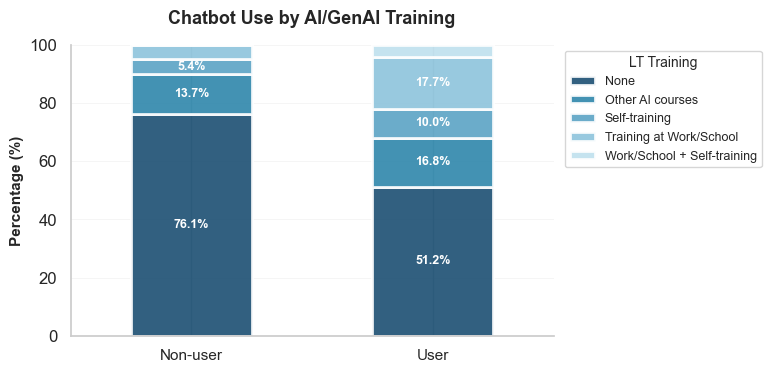

In [36]:
# Map ALL Italian labels to English - with correct accents
education_mapping = {
    'No': 'None',
    'No, ma ho seguito corsi su altre tecnologie di Intelligenza Artificiale': 'Other AI courses',
    'Sì, cercati in autonomia': 'Self-training',
    'Sì, sul posto di lavoro/a scuola': 'Training at Work/School',
    'Sì, sul posto di lavoro/a scuola,Sì, cercati in autonomia': 'Work/School + Self-training'
}

# Create chatbot usage mapping
df_clean['chatbot_used_en'] = df_clean['chatbot_user'].map({
    'Yes': 'User',
    'No': 'Non-user'
})

# Map education to English
df_clean['education_technology_en'] = df_clean['education_technology'].map(education_mapping)

# Check for unmapped values
unmapped = df_clean[df_clean['education_technology_en'].isna()]['education_technology'].unique()
if len(unmapped) > 0:
    print(f"WARNING: Unmapped education values: {unmapped}")

# Create cross-tabulation
cross = pd.crosstab(df_clean['chatbot_used_en'], df_clean['education_technology_en'], margins=True)

# Calculate percentages
cross_pct = cross.div(cross['All'], axis=0) * 100

# Remove totals for plotting
cross_pct = cross_pct.drop(columns='All').drop(index='All')

# Create more compact plot
fig, ax = plt.subplots(figsize=(8, 4))

# Use more distinct colors with better contrast
colors = ['#1B4F72', '#2E86AB', '#5BA3C5', '#8DC4DC', '#BFE0EE']

# Create stacked bar plot
bars = cross_pct.plot(kind='bar', stacked=True, ax=ax, 
              color=colors, alpha=0.9, edgecolor='white', linewidth=2)

# White background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Add percentage labels on bars for readability
for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 5 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', 
                fontsize=9, fontweight='bold', color='white')

# Styling
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xlabel('', fontsize=11)
ax.set_title('Chatbot Use by AI/GenAI Training', fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.set_ylim(0, 100)

# Minimal grid
ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5, color='lightgray')
ax.set_axisbelow(True)

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Compact legend
ax.legend(title='LT Training', 
         bbox_to_anchor=(1.01, 1), 
         loc='upper left',
         frameon=True,
         fontsize=9,
         title_fontsize=10)

plt.tight_layout()
plt.savefig('../figures/lt_course.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('../figures/lt_course.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## Activities count by Age and Gender

In [29]:
# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Distribution of Activities per User by Demographics', fontsize=20, fontweight='bold')

colors = ['#2E86AB', '#A23B72', '#95a5a6']
start_color = '#8DC4DC'
end_color = '#1B4F72'
custom_cmap = LinearSegmentedColormap.from_list("custom_blue", [start_color, end_color])

# ==============================================================================
# PANEL C BY AGE GROUP (Left)
# ==============================================================================
ax_c_age = axes[0]

if 'Q52' in df_clean.columns and 'AgeGroup' in df_clean.columns:
    age_groups_sorted = sorted(df_clean['AgeGroup'].dropna().unique())
    n_age_groups = len(age_groups_sorted)
    colors_age = custom_cmap(np.linspace(0, 1, n_age_groups))
    
    for idx, age in enumerate(age_groups_sorted):
        age_subset = df_clean[df_clean['AgeGroup'] == age]
        
        activity_counts = (
            age_subset['Q52']
            .dropna()
            .str.split(',')
            .apply(lambda x: len([i.strip() for i in x if i.strip() not in ['Altro', 'Nessuna di queste']]))
        )
        
        if len(activity_counts) > 0:
            hist_data = activity_counts.value_counts().sort_index()
            avg_activities = activity_counts.mean()
            n_users = len(activity_counts)
            
            ax_c_age.plot(hist_data.index, hist_data.values, 
                         marker='o', linewidth=2.5, markersize=10,
                         label=f'{age} (avg: {avg_activities:.1f}, n={n_users})',
                         color=colors_age[idx], alpha=0.8)
    
    ax_c_age.set_xlabel('Number of Activities', fontsize=16, fontweight='bold')
    ax_c_age.set_ylabel('Number of Users', fontsize=16, fontweight='bold')
    ax_c_age.set_title('Distribution of Activities by Age Group', fontsize=16, fontweight='bold')
    ax_c_age.legend(loc='upper right', fontsize=16)
    ax_c_age.grid(True, alpha=0.2, linestyle='--')

# ==============================================================================
# PANEL C BY GENDER (Right) - Only Man and Woman
# ==============================================================================
ax_c_gender = axes[1]

if 'Q52' in df_clean.columns and 'GenderGroup' in df_clean.columns:
    # Filter for only Man and Woman
    df_gender_filtered = df_clean[df_clean['GenderGroup'].isin(['Man', 'Woman'])]
    
    gender_groups_sorted = sorted(df_gender_filtered['GenderGroup'].dropna().unique())
    n_genders = len(gender_groups_sorted)
    colors_gender = custom_cmap(np.linspace(0, 1, n_genders))
    
    for idx, gender in enumerate(gender_groups_sorted):
        gender_subset = df_gender_filtered[df_gender_filtered['GenderGroup'] == gender]
        
        activity_counts = (
            gender_subset['Q52']
            .dropna()
            .str.split(',')
            .apply(lambda x: len([i.strip() for i in x if i.strip() not in ['Altro', 'Nessuna di queste']]))
        )
        
        if len(activity_counts) > 0:
            hist_data = activity_counts.value_counts().sort_index()
            avg_activities = activity_counts.mean()
            n_users = len(activity_counts)
            
            ax_c_gender.plot(hist_data.index, hist_data.values, 
                           marker='o', linewidth=2.5, markersize=10,
                           label=f'{gender} (avg: {avg_activities:.1f}, n={n_users})',
                           color=colors_gender[idx], alpha=0.8)
    
    ax_c_gender.set_xlabel('Number of Activities', fontsize=16, fontweight='bold')
    ax_c_gender.set_ylabel('Number of Users', fontsize=16, fontweight='bold')
    ax_c_gender.set_title('Distribution of Activities by Gender', fontsize=16, fontweight='bold')
    ax_c_gender.legend(loc='upper right', fontsize=16)
    ax_c_gender.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig('../figures/genai_activities_demographics.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/genai_activities_demographics.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Extras

In [28]:
# Get ALL activities
q53_columns = [col for col in q53_to_label_en.keys() if col in df_clean.columns]

# Filter for chatbot users only
df_chatbot = df_clean[df_clean['chatbot_user'] == 'Yes']

all_activities = []
for col in q53_columns:
    activity_label = q53_to_label_en.get(col, col)
    count = df_chatbot[col].notna().sum()
    all_activities.append((activity_label, count))

# Sort by total usage
all_activities_sorted = [act[0] for act in sorted(all_activities, key=lambda x: x[1], reverse=True)]

# Create custom blue palette
start_color = '#BFE0EE'  # Light blue
end_color = '#1B4F72'    # Dark blue
custom_cmap = LinearSegmentedColormap.from_list("custom_blue", [start_color, end_color])

# ==============================================================================
# BY AGE GROUP (Activities on Y-axis, horizontal bars) - CHATBOT USERS ONLY
# ==============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 24))

if 'AgeGroup' in df_chatbot.columns:
    age_groups = sorted(df_chatbot['AgeGroup'].dropna().unique())
    
    # Calculate percentages
    age_data = {}
    age_sizes = {}
    
    for age in age_groups:
        age_subset = df_chatbot[df_chatbot['AgeGroup'] == age]
        age_sizes[age] = len(age_subset)
        age_data[age] = []
        
        for activity in all_activities_sorted:
            # Find the column for this activity
            col = None
            for c in q53_columns:
                if q53_to_label_en.get(c, c) == activity:
                    col = c
                    break
            
            if col and col in age_subset.columns:
                count = age_subset[col].notna().sum()
                pct = (count / age_sizes[age]) * 100 if age_sizes[age] > 0 else 0
            else:
                pct = 0
            
            age_data[age].append(pct)
    
    # Plot horizontal bars
    y = np.arange(len(all_activities_sorted))
    height = 0.8 / len(age_groups)
    
    colors_age = custom_cmap(np.linspace(0, 1, len(age_groups)))
    
    for i, age in enumerate(age_groups):
        offset = (i - len(age_groups)/2 + 0.5) * height
        bars = ax1.barh(y + offset, age_data[age], height, 
                       label=f'{age} (n={age_sizes[age]})', 
                       alpha=0.85, color=colors_age[i])
    
    ax1.set_ylabel('Activities', fontsize=16, fontweight='bold')
    ax1.set_xlabel('% of Age Group Using Activity', fontsize=16, fontweight='bold')
    ax1.set_title('Activity Usage by Age Group (Chatbot Users)', fontsize=18, fontweight='bold', pad=20)
    ax1.set_yticks(y)
    ax1.set_yticklabels(all_activities_sorted, fontsize=13)
    ax1.legend(loc='lower right', fontsize=13, framealpha=0.9)
    ax1.grid(True, alpha=0.3, axis='x')
    ax1.tick_params(axis='both', which='major', labelsize=13)
    ax1.set_xlim(0, 100)

# ==============================================================================
# BY GENDER (Activities on Y-axis, horizontal bars) - CHATBOT USERS ONLY
# ==============================================================================

if 'GenderGroup' in df_chatbot.columns:
    df_gender = df_chatbot[df_chatbot['GenderGroup'].isin(['Man', 'Woman'])]
    gender_groups = sorted(df_gender['GenderGroup'].dropna().unique())
    
    # Calculate percentages
    gender_data = {}
    gender_sizes = {}
    
    for gender in gender_groups:
        gender_subset = df_gender[df_gender['GenderGroup'] == gender]
        gender_sizes[gender] = len(gender_subset)
        gender_data[gender] = []
        
        for activity in all_activities_sorted:
            # Find the column for this activity
            col = None
            for c in q53_columns:
                if q53_to_label_en.get(c, c) == activity:
                    col = c
                    break
            
            if col and col in gender_subset.columns:
                count = gender_subset[col].notna().sum()
                pct = (count / gender_sizes[gender]) * 100 if gender_sizes[gender] > 0 else 0
            else:
                pct = 0
            
            gender_data[gender].append(pct)
    
    # Plot horizontal bars
    y = np.arange(len(all_activities_sorted))
    height = 0.35
    
    colors_gender = custom_cmap(np.linspace(0.2, 0.8, len(gender_groups)))
    
    for i, gender in enumerate(gender_groups):
        offset = (i - 0.5) * height
        bars = ax2.barh(y + offset, gender_data[gender], height, 
                       label=f'{gender} (n={gender_sizes[gender]})', 
                       alpha=0.85, color=colors_gender[i])
    
    ax2.set_ylabel('Activities', fontsize=16, fontweight='bold')
    ax2.set_xlabel('% of Gender Group Using Activity', fontsize=16, fontweight='bold')
    ax2.set_title('Activity Usage by Gender (Chatbot Users)', fontsize=18, fontweight='bold', pad=20)
    ax2.set_yticks(y)
    ax2.set_yticklabels(all_activities_sorted, fontsize=13)
    ax2.legend(loc='lower right', fontsize=13, framealpha=0.9)
    ax2.grid(True, alpha=0.3, axis='x')
    ax2.tick_params(axis='both', which='major', labelsize=13)
    ax2.set_xlim(0, 100)

plt.tight_layout()
# plt.savefig('../figures/activities_by_demographics_bars.png', dpi=300, bbox_inches='tight')
# plt.savefig('../figures/activities_by_demographics_bars.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

def binomial_ci(count, total, confidence=0.95):
    """Calculate binomial confidence interval using Wilson score interval"""
    if total == 0:
        return 0, 0, 0
    
    p = count / total
    z = stats.norm.ppf((1 + confidence) / 2)
    
    denominator = 1 + z**2 / total
    centre = (p + z**2 / (2 * total)) / denominator
    adjustment = z * np.sqrt((p * (1 - p) + z**2 / (4 * total)) / total) / denominator
    
    ci_lower = max(0, centre - adjustment) * 100
    ci_upper = min(1, centre + adjustment) * 100
    
    return p * 100, ci_lower, ci_upper

# Select specific activities
selected_activities = {
    "Q53_5": "Text Analysis",
    "Q53_7": "Explanations",
    #"Q53_10": "Travel Planning",
    "Q53_11": "Fact Checking",
    "Q53_12": "Personal Advice",
    "Q53_13": "Medical Advice",
    "Q53_15": "Emotional Support",
    "Q53_20": "Programming Help",
    "Q53_21": "Data Analysis"
}

# Filter for chatbot users only
df_chatbot = df_clean[df_clean['chatbot_user'] == 'Yes']

# Get activity counts and sort
activity_counts = []
for col, label in selected_activities.items():
    if col in df_chatbot.columns:
        count = df_chatbot[col].notna().sum()
        activity_counts.append((label, count, col))

# Sort by total usage
activity_counts_sorted = sorted(activity_counts, key=lambda x: x[1], reverse=True)
activities_sorted = [act[0] for act in activity_counts_sorted]
columns_sorted = [act[2] for act in activity_counts_sorted]

# Create custom blue palette
start_color = '#BFE0EE'  # Light blue
end_color = '#1B4F72'    # Dark blue
custom_cmap = LinearSegmentedColormap.from_list("custom_blue", [start_color, end_color])

# ==============================================================================
# BY AGE GROUP (Activities on Y-axis, horizontal bars) - WITH 95% CI
# ==============================================================================

fig, ax = plt.subplots(1, 1, figsize=(16, 10))

if 'AgeGroup' in df_chatbot.columns:
    age_groups = sorted(df_chatbot['AgeGroup'].dropna().unique())
    
    # Calculate percentages with CI
    age_data = {}
    age_ci_lower = {}
    age_ci_upper = {}
    age_sizes = {}
    
    for age in age_groups:
        age_subset = df_chatbot[df_chatbot['AgeGroup'] == age]
        age_sizes[age] = len(age_subset)
        age_data[age] = []
        age_ci_lower[age] = []
        age_ci_upper[age] = []
        
        for col in columns_sorted:
            if col in age_subset.columns:
                count = age_subset[col].notna().sum()
                pct, ci_low, ci_high = binomial_ci(count, age_sizes[age])
            else:
                pct, ci_low, ci_high = 0, 0, 0
            
            age_data[age].append(pct)
            age_ci_lower[age].append(ci_low)
            age_ci_upper[age].append(ci_high)
    
    # Plot horizontal bars with error bars
    y = np.arange(len(activities_sorted))
    height = 0.8 / len(age_groups)
    
    colors_age = custom_cmap(np.linspace(0, 1, len(age_groups)))
    
    for i, age in enumerate(age_groups):
        offset = (i - len(age_groups)/2 + 0.5) * height
        y_positions = y + offset
        
        # Plot bars
        bars = ax.barh(y_positions, age_data[age], height, label=f'{age} (n={age_sizes[age]})', alpha=0.85, color=colors_age[i])
        
        # Calculate error bar values
        xerr_lower = np.array(age_data[age]) - np.array(age_ci_lower[age])
        xerr_upper = np.array(age_ci_upper[age]) - np.array(age_data[age])
        
        # Add error bars
        ax.errorbar(age_data[age], y_positions, 
                   xerr=[xerr_lower, xerr_upper],
                   fmt='none', ecolor='black', alpha=0.5, capsize=3, capthick=1.5,linewidth=1.5,zorder=10)
    
    #ax.set_ylabel('Activities', fontsize=16, fontweight='bold')
    ax.set_xlabel('% of Age Group Using Activity [95% CI]', fontsize=16, fontweight='bold')
    ax.set_title('Activity Usage by Age Group', fontsize=18, fontweight='bold', pad=20)
    ax.set_yticks(y)
    ax.set_yticklabels(activities_sorted, fontsize=14)
    ax.legend(loc='upper right', fontsize=13, framealpha=0.9)
    ax.grid(True, alpha=0.3, axis='x')
    ax.tick_params(axis='both', which='major', labelsize=13)
    
    # Set x-axis limit to accommodate error bars
    max_val = max([max(age_ci_upper[age]) for age in age_groups])
    ax.set_xlim(0, max_val * 1.1)

plt.tight_layout()
plt.savefig('../figures/activities_by_age_selected_ci.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/activities_by_age_selected_ci.pdf', dpi=300, bbox_inches='tight')
plt.show()

# print("Figure saved as PNG and PDF!")
# print(f"Total chatbot users: {len(df_chatbot)}")
# print(f"Total activities displayed: {len(activities_sorted)}")
# print(f"\nChatbot users by age group:")
# for age, size in age_sizes.items():
#     print(f"  {age}: n={size}")
# print(f"\nActivities (sorted by usage) with 95% CI:")
# for i, (label, count, col) in enumerate(activity_counts_sorted, 1):
#     pct, ci_low, ci_high = binomial_ci(count, len(df_chatbot))
#     print(f"  {i}. {label}: {count} users ({pct:.1f}% [95% CI: {ci_low:.1f}%-{ci_high:.1f}%])")

In [53]:
# Select specific activities
selected_activities = {
    "Q53_5": "Text Analysis",
    "Q53_7": "Explanations",
    #"Q53_10": "Travel Planning",
    "Q53_11": "Fact Checking",
    "Q53_12": "Personal Advice",
    "Q53_13": "Medical Advice",
    "Q53_15": "Emotional Support",
    "Q53_20": "Programming Help",
    "Q53_21": "Data Analysis"
}

# Filter for chatbot users only
df_chatbot = df_clean[df_clean['chatbot_user'] == 'Yes']

# Get activity counts and sort
activity_counts = []
for col, label in selected_activities.items():
    if col in df_chatbot.columns:
        count = df_chatbot[col].notna().sum()
        activity_counts.append((label, count, col))

# Sort by total usage
activity_counts_sorted = sorted(activity_counts, key=lambda x: x[1], reverse=True)
activities_sorted = [act[0] for act in activity_counts_sorted]
columns_sorted = [act[2] for act in activity_counts_sorted]

# Create custom blue palette
start_color = '#BFE0EE'  # Light blue
end_color = '#1B4F72'    # Dark blue
custom_cmap = LinearSegmentedColormap.from_list("custom_blue", [start_color, end_color])

# ==============================================================================
# BY AGE GROUP (Activities on Y-axis, horizontal bars) - WITH 95% CI
# ==============================================================================

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

if 'AgeGroup' in df_chatbot.columns:
    age_groups = sorted(df_chatbot['AgeGroup'].dropna().unique())
    
    # Calculate percentages with CI
    age_data = {}
    age_ci_lower = {}
    age_ci_upper = {}
    age_sizes = {}
    
    for age in age_groups:
        age_subset = df_chatbot[df_chatbot['AgeGroup'] == age]
        age_sizes[age] = len(age_subset)
        age_data[age] = []
        age_ci_lower[age] = []
        age_ci_upper[age] = []
        
        for col in columns_sorted:
            if col in age_subset.columns:
                count = age_subset[col].notna().sum()
                pct, ci_low, ci_high = binomial_ci(count, age_sizes[age])
            else:
                pct, ci_low, ci_high = 0, 0, 0
            
            age_data[age].append(pct)
            age_ci_lower[age].append(ci_low)
            age_ci_upper[age].append(ci_high)
    
    # Plot horizontal bars with error bars
    y = np.arange(len(activities_sorted))
    height = 0.8 / len(age_groups)
    
    colors_age = custom_cmap(np.linspace(0, 1, len(age_groups)))
    
    for i, age in enumerate(age_groups):
        offset = (i - len(age_groups)/2 + 0.5) * height
        y_positions = y + offset
        
        # Plot bars
        bars = ax.barh(y_positions, age_data[age], height, label=f'{age} (n={age_sizes[age]})', alpha=0.85, color=colors_age[i])
        
        # Calculate error bar values
        xerr_lower = np.array(age_data[age]) - np.array(age_ci_lower[age])
        xerr_upper = np.array(age_ci_upper[age]) - np.array(age_data[age])
        
        # Add error bars
        ax.errorbar(age_data[age], y_positions, 
                   xerr=[xerr_lower, xerr_upper],
                   fmt='none', ecolor='black', alpha=0.5, capsize=3, capthick=1.5, linewidth=1.5, zorder=10)
    
    ax.set_xlabel('% of Age Group Using Activity [95% CI]')
    ax.set_title('Activity Usage by Age Group', pad=20)
    ax.set_yticks(y)
    ax.set_yticklabels(activities_sorted)
    ax.legend(loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.3, axis='x')
    
    # Set x-axis limit to accommodate error bars
    max_val = max([max(age_ci_upper[age]) for age in age_groups])
    ax.set_xlim(0, max_val * 1.1)

plt.tight_layout()
# plt.savefig('../figures/activities_by_age_selected_ci.png', dpi=300, bbox_inches='tight')
# plt.savefig('../figures/activities_by_age_selected_ci.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [54]:
# Select specific activities
selected_activities = {
    "Q53_5": "Text Analysis",
    "Q53_7": "Explanations",
    #"Q53_10": "Travel Planning",
    "Q53_11": "Fact Checking",
    "Q53_12": "Personal Advice",
    "Q53_13": "Medical Advice",
    "Q53_15": "Emotional Support",
    "Q53_20": "Programming Help",
    "Q53_21": "Data Analysis"
}

# Filter for chatbot users only
df_chatbot = df_clean[df_clean['chatbot_user'] == 'Yes']

# Get activity counts and sort
activity_counts = []
for col, label in selected_activities.items():
    if col in df_chatbot.columns:
        count = df_chatbot[col].notna().sum()
        activity_counts.append((label, count, col))

# Sort by total usage
activity_counts_sorted = sorted(activity_counts, key=lambda x: x[1], reverse=True)
activities_sorted = [act[0] for act in activity_counts_sorted]
columns_sorted = [act[2] for act in activity_counts_sorted]

# Create custom blue palette
start_color = '#BFE0EE'  # Light blue
end_color = '#1B4F72'    # Dark blue
custom_cmap = LinearSegmentedColormap.from_list("custom_blue", [start_color, end_color])

# ==============================================================================
# BY AGE GROUP (Age groups on Y-axis, vertical bars) - WITH 95% CI
# ==============================================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

if 'AgeGroup' in df_chatbot.columns:
    age_groups = sorted(df_chatbot['AgeGroup'].dropna().unique())
    
    # Calculate percentages with CI
    age_data = {}
    age_ci_lower = {}
    age_ci_upper = {}
    age_sizes = {}
    
    for age in age_groups:
        age_subset = df_chatbot[df_chatbot['AgeGroup'] == age]
        age_sizes[age] = len(age_subset)
        age_data[age] = []
        age_ci_lower[age] = []
        age_ci_upper[age] = []
        
        for col in columns_sorted:
            if col in age_subset.columns:
                count = age_subset[col].notna().sum()
                pct, ci_low, ci_high = binomial_ci(count, age_sizes[age])
            else:
                pct, ci_low, ci_high = 0, 0, 0
            
            age_data[age].append(pct)
            age_ci_lower[age].append(ci_low)
            age_ci_upper[age].append(ci_high)
    
    # Plot vertical bars with error bars
    x = np.arange(len(activities_sorted))
    width = 0.8 / len(age_groups)
    
    colors_age = custom_cmap(np.linspace(0, 1, len(age_groups)))
    
    for i, age in enumerate(age_groups):
        offset = (i - len(age_groups)/2 + 0.5) * width
        x_positions = x + offset
        
        # Plot bars
        bars = ax.bar(x_positions, age_data[age], width, 
                     label=f'{age} (n={age_sizes[age]})', 
                     alpha=0.85, color=colors_age[i])
        
        # Calculate error bar values
        yerr_lower = np.array(age_data[age]) - np.array(age_ci_lower[age])
        yerr_upper = np.array(age_ci_upper[age]) - np.array(age_data[age])
        
        # Add error bars
        ax.errorbar(x_positions, age_data[age], 
                   yerr=[yerr_lower, yerr_upper],
                   fmt='none', ecolor='black', alpha=0.5, 
                   capsize=3, capthick=1.5, linewidth=1.5, zorder=10)
    
    #ax.set_xlabel('Activities')
    ax.set_ylabel('% of Age Group performing Activity')
    ax.set_title('Activity Usage by Age Group', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(activities_sorted, rotation=45, ha='right')
    ax.legend(loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set y-axis limit to accommodate error bars
    max_val = max([max(age_ci_upper[age]) for age in age_groups])
    ax.set_ylim(0, max_val * 1.1)

plt.tight_layout()
plt.savefig('../figures/activities_by_age_selected_ci.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/activities_by_age_selected_ci.pdf', dpi=300, bbox_inches='tight')
plt.show()